# Full Method 1 Notebook

This notebook is a self-contained, research-oriented implementation of **Method 1 (KG-GT)** from `method1.tex`.

It keeps the current project choice of **MSE-only practical training** by default:

- The architecture includes the Transformer and GAT path.
- `SoftDTW` is still inlined below for completeness.
- The default config uses `loss_lambda = 1.0`, so training remains resource-aware.

## Method 1 Audit

`docs/report.tex` includes Method 1 via `data/review/EEGtoEMG/Final/report/method1.tex`.

Implementation status against the report:

- EEG preprocessing: implemented
- EMG preprocessing: implemented
- Kinematic state vector: implemented
- CCA alignment: implemented
- Transformer temporal encoder: implemented
- Kinematic-guided GAT path: implemented
- Hybrid MSE + SoftDTW loss: implemented in code, but current config intentionally runs MSE-only
- Training/evaluation pipeline: implemented

The main missing deliverable was a **single self-contained notebook** for study, inspection, and paper-ready visualization. This notebook fills that gap.

In [1]:
# @title EnvironmentAndImports
from __future__ import annotations

import copy
import io
import json
import logging
import math
import os
import random
import re
import sys
import time
import csv
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import seaborn as sns
import yaml
from scipy.signal import butter, decimate, filtfilt, iirnotch, savgol_filter, sosfiltfilt
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Subset,DataLoader, Dataset

# try:
#     from tqdm.auto import tqdm
#     _TQDM_AVAILABLE = True
# except ImportError:
#     _TQDM_AVAILABLE = False
try:
    from tqdm.notebook import tqdm
    _TQDM_AVAILABLE = True
except ImportError:
    _TQDM_AVAILABLE = False

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CONFIG_PATH = ROOT / "configs" / "default.yaml"
METHOD1_TEX_PATH = ROOT / "data" / "review" / "EEGtoEMG" / "Final" / "report" / "method1.tex"
logger = logging.getLogger("method1_notebook")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

In [ ]:
# @title Config
cfg = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "raw_dir": "data/way-eeg/raw",
        "cache_dir": "data/cache",
        "participants": [2],             # Reduced to 1 subject for lighter memory footprint
        "window_size": 500,              # samples at 500 Hz = 0.5 s, lower sequence cost for current GPU
        "stride": 150,                   # 100 ms between windows, far fewer overlapping windows than stride 15
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 13             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.1,               # Hz, bandpass lower bound
            "bp_high": 40.0,             # Hz, bandpass upper bound
            "filter_order": 4,
            "notch_freq": 50.0,          # Hz, power-line
            "asr_window_ms": 500,        # ms, ASR sliding window
            "asr_std_thresh": 5.0,       # sigma, ASR rejection threshold
            "delta_low": 0.1,            # Hz, delta-band lower bound
            "delta_high": 2.0,           # Hz, delta-band upper bound
            "target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 10.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": False,   # if true, output is (T, 26) = k_t + velocity
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
        "cca": {
            "n_components": 8,           # canonical components; bounded by min(n_eeg, n_kin)=min(8,13)=8
            "max_fit_samples": 100000,
            "random_state": 42
        }
    },
    "model": {
        "type": "transformer_regressor",
        "eeg_dim": 32,
        "kin_dim": 13,
        "d_model": 64,
        "transformer": {
            "n_layers": 4,               # Reduced from 4
            "n_heads": 8,                # Reduced from 8
            "d_model": 128,              # Reduced from 256
            "d_k": 32,                   # Reduced from 32
            "d_v": 32,                   # Reduced from 32
            "ffn_dim": 512,              # Reduced from 1024
            "dropout": 0.1
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": False
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        "optimizer": "adamw",
        "weight_decay": 0.001,
        "lr": 0.00005,
        "lr_patience": 50,             # epochs without val improvement before halving
        "lr_factor": 0.5,
        "batch_size": 64,              # Safer true micro-batch for current GPU
        "gradient_accumulation_steps": 2, # Effective batch size 32 with lower peak VRAM
        "early_stop_patience": 30,     # epochs
        "grad_clip_norm": 1.0,
        "max_epochs": 50,
        "loss_lambda": 1.0,            # weight of MSE vs SoftDTW. Set to 1.0 to disable slow Python SoftDTW!
        "soft_dtw_gamma": 0.1,         # SoftDTW smoothing parameter
        "use_amp": True,
        "log_memory_every": 50,
        "losocv": True,                # leave-one-subject-out cross-validation
        "seed": 42,
    },
    "runtime": {
        "num_workers": 0,
        "pin_memory": True,
        "persistent_workers": False,
        "prefetch_factor": 2
    }
}


In [232]:
# @title LoadProjectConfig
# with open(CONFIG_PATH, encoding="utf-8") as fh:
#     cfg = yaml.safe_load(fh)

# print("Config path:", CONFIG_PATH)
# print("Model type:", cfg["model"]["type"])
# print("Current loss_lambda:", cfg["training"]["loss_lambda"])
# print("Participants:", cfg["data"]["participants"])
# print("Window size / stride:", cfg["data"]["window_size"], cfg["data"]["stride"])

In [3]:
# @title Device

"""
Device selection and reproducible seeding for GPU training.

get_device() picks CUDA when available and falls back to CPU, so the same
code path runs on the GTX 1660 Ti and on a CPU-only machine. set_seed()
seeds Python, NumPy, and torch (CPU + CUDA) for reproducible runs.
"""

from __future__ import annotations

import logging
import os
import random

import numpy as np
import torch

logger = logging.getLogger(__name__)


def get_device(prefer_cuda: bool = True) -> torch.device:
    """Return the best available compute device.

    Args:
        prefer_cuda: When True (default), use CUDA if available.

    Returns:
        torch.device('cuda') if available and preferred, else torch.device('cpu').
    """
    if prefer_cuda and torch.cuda.is_available():
        device = torch.device("cuda")
        name = torch.cuda.get_device_name(0)
        total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        logger.info("Using CUDA device: %s (%.1f GB)", name, total_gb)
        return device

    if prefer_cuda:
        logger.warning(
            "CUDA not available (torch=%s). Falling back to CPU. "
            "If you expected GPU, reinstall the CUDA build: "
            "pip install torch==2.8.0 --index-url "
            "https://download.pytorch.org/whl/cu126",
            torch.__version__,
        )
    return torch.device("cpu")


def set_seed(seed: int = 42, deterministic: bool = True) -> None:
    """Seed all RNGs for reproducibility.

    Args:
        seed: Random seed.
        deterministic: When True, force deterministic cuDNN kernels. This
            improves reproducibility at some throughput cost; set False to let
            cuDNN autotune for speed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic

In [4]:
# @title dataloader
"""
WAY-EEG-GAL .mat file loader.

Handles two file types:
  HS_PX_SY.mat  — continuous whole-series data (struct: hs)
  WS_PX_SY.mat  — windowed per-trial data      (struct: ws)

scipy.io.loadmat is called with squeeze_me=True, struct_as_record=False
so nested MATLAB structs are accessible as Python attributes.
"""

from __future__ import annotations

import re
from pathlib import Path
from typing import Union

import numpy as np
import scipy.io as sio

# ---------------------------------------------------------------------------
# Split definitions (series numbers per participant)
# ---------------------------------------------------------------------------

TRAIN_SERIES: list = list(range(1, 8))   # S1–S7
VAL_SERIES:   list = [8]                 # S8
TEST_SERIES:  list = [9]                 # S9
STAB_SERIES:  list = ["ST"]             # ST (stability / perturbation)

_SPLIT_MAP = {
    "train":     TRAIN_SERIES,
    "val":       VAL_SERIES,
    "test":      TEST_SERIES,
    "stability": STAB_SERIES,
    "all":       TRAIN_SERIES + VAL_SERIES + TEST_SERIES + STAB_SERIES,
}


def get_split_series(split: str) -> list:
    """Return series identifiers for the requested split.

    Args:
        split: one of 'train', 'val', 'test', 'stability', 'all'

    Returns:
        List of series identifiers (int or 'ST').
    """
    if split not in _SPLIT_MAP:
        raise ValueError(f"Unknown split '{split}'. Choose from {list(_SPLIT_MAP)}")
    return _SPLIT_MAP[split]


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _mat_load(path: Union[str, Path]) -> dict:
    """Load a .mat file with squeeze_me and struct_as_record=False."""
    return sio.loadmat(
        str(path),
        squeeze_me=True,
        struct_as_record=False,
        mat_dtype=False,
    )


def _to_f32(arr: np.ndarray) -> np.ndarray:
    return np.asarray(arr, dtype=np.float32)


def _names_to_list(names_field) -> list[str]:
    """Convert MATLAB cell/string array of channel names to Python list."""
    if isinstance(names_field, np.ndarray):
        flat = names_field.flatten()
        return [str(n).strip() for n in flat]
    if isinstance(names_field, str):
        return [names_field.strip()]
    return list(names_field)


def _series_id_from_filename(fname: str) -> Union[int, str]:
    """Extract series ID: 'HS_P1_S3.mat' -> 3, 'HS_P1_ST.mat' -> 'ST'."""
    name = Path(fname).stem.upper()
    match = re.search(r"_S(\d+|ST)$", name)
    if match is None:
        raise ValueError(f"Cannot parse series ID from filename: {fname}")
    raw = match.group(1)
    return int(raw) if raw.isdigit() else raw


# ---------------------------------------------------------------------------
# HS loader  (continuous whole-series)
# ---------------------------------------------------------------------------

def load_hs(path: Union[str, Path]) -> dict:
    """Load one HS_PX_SY.mat file.

    Returns a dict with:
        eeg        : ndarray (T_eeg, 32)   float32, uV
        emg        : ndarray (T_emg, 5)    float32, raw units
        kin        : ndarray (T_kin, 36)   float32, mm / N / N*mm
        fs_eeg     : int    sampling rate EEG  (500 Hz)
        fs_emg     : int    sampling rate EMG  (4000 Hz)
        fs_kin     : int    sampling rate kin  (500 Hz)
        eeg_names  : list[str]  32 channel labels
        emg_names  : list[str]  5 muscle labels
        kin_names  : list[str]  36 kinematic channel labels
        participant: int
        series     : int | str  (numeric or 'ST')
        path       : str
    """
    path = Path(path)
    mat = _mat_load(path)
    hs = mat["hs"]

    eeg_sig = _to_f32(hs.eeg.sig)
    emg_sig = _to_f32(hs.emg.sig)
    kin_sig = _to_f32(hs.kin.sig)

    # Ensure 2-D even if single channel
    if eeg_sig.ndim == 1:
        eeg_sig = eeg_sig[:, None]
    if emg_sig.ndim == 1:
        emg_sig = emg_sig[:, None]
    if kin_sig.ndim == 1:
        kin_sig = kin_sig[:, None]

    fs_eeg = int(np.asarray(hs.eeg.samplingrate).flat[0])
    fs_emg = int(np.asarray(hs.emg.samplingrate).flat[0])
    fs_kin = int(np.asarray(hs.kin.samplingrate).flat[0])

    eeg_names = _names_to_list(hs.eeg.names)
    emg_names = _names_to_list(hs.emg.names)
    kin_names = _names_to_list(hs.kin.names)

    participant = int(np.asarray(hs.participant).flat[0])
    series = _series_id_from_filename(path.name)

    return {
        "eeg":         eeg_sig,
        "emg":         emg_sig,
        "kin":         kin_sig,
        "fs_eeg":      fs_eeg,
        "fs_emg":      fs_emg,
        "fs_kin":      fs_kin,
        "eeg_names":   eeg_names,
        "emg_names":   emg_names,
        "kin_names":   kin_names,
        "participant": participant,
        "series":      series,
        "path":        str(path),
    }


# ---------------------------------------------------------------------------
# WS loader  (windowed per-trial)
# ---------------------------------------------------------------------------

def _scalar(x) -> float:
    return float(np.asarray(x).flat[0])


def load_ws(path: Union[str, Path]) -> list[dict]:
    """Load one WS_PX_SY.mat file.

    Returns a list of trial dicts (one per lift), each with:
        eeg             : ndarray (T_eeg, 32)  float32
        emg             : ndarray (T_emg, 5)   float32
        kin             : ndarray (T_kin, 45)  float32  (36 raw + 9 derived)
        eeg_t           : ndarray (T_eeg,)     time vector (s)
        emg_t           : ndarray (T_emg,)     time vector (s)
        weight          : int    1=165g, 2=330g, 4=660g
        surf            : int    1=sandpaper, 2=suede, 3=silk
        weight_id       : str
        surf_id         : str
        led_on          : float  (s, relative to trial window)
        led_off         : float
        trial_start_time: float  (s, absolute within series)
        trial_idx       : int    0-based index within series
        participant     : int
        series          : int | str
        path            : str
    """
    path = Path(path)
    mat = _mat_load(path)
    ws = mat["ws"]

    wins = ws.win
    if not hasattr(wins, "__len__"):
        wins = [wins]

    participant = int(np.asarray(ws.participantnum).flat[0])
    series = _series_id_from_filename(path.name)

    trials = []
    for i, w in enumerate(wins):
        trial = {
            "eeg":              _to_f32(w.eeg),
            "emg":              _to_f32(w.emg),
            "kin":              _to_f32(w.kin),
            "eeg_t":            _to_f32(w.eeg_t),
            "emg_t":            _to_f32(w.emg_t),
            "weight":           int(_scalar(w.weight)),
            "surf":             int(_scalar(w.surf)),
            "weight_id":        str(w.weight_id).strip(),
            "surf_id":          str(w.surf_id).strip(),
            "led_on":           _scalar(w.LEDon),
            "led_off":          _scalar(w.LEDoff),
            "trial_start_time": _scalar(w.trial_start_time),
            "trial_idx":        i,
            "participant":      participant,
            "series":           series,
            "path":             str(path),
        }
        trials.append(trial)

    return trials


# ---------------------------------------------------------------------------
# Participant-level loader
# ---------------------------------------------------------------------------

def load_participant(
    data_dir: Union[str, Path],
    participant: int,
    file_type: str = "hs",
    series: list | None = None,
    include_stability: bool = True,
) -> list[dict]:
    """Load all requested series for one participant.

    Args:
        data_dir:          Root directory containing P1/, P2/, ... subdirs.
        participant:       Participant number 1-12.
        file_type:         'hs' (continuous) or 'ws' (per-trial windowed).
        series:            List of series IDs to load (ints and/or 'ST').
                           None = load all available.
        include_stability: When series=None, include the ST series.

    Returns:
        List of series dicts (load_hs) or lists of trial dicts (load_ws),
        sorted by series number with ST appended last.
    """
    data_dir = Path(data_dir)
    p_dir = data_dir / f"P{participant}"
    if not p_dir.exists():
        raise FileNotFoundError(f"Participant directory not found: {p_dir}")

    prefix = file_type.upper()
    found_files = sorted(p_dir.glob(f"{prefix}_P{participant}_S*.mat"))

    if not found_files:
        raise FileNotFoundError(
            f"No {prefix} files found for P{participant} in {p_dir}"
        )

    series_map: dict[Union[int, str], Path] = {}
    for f in found_files:
        try:
            sid = _series_id_from_filename(f.name)
        except ValueError:
            continue
        series_map[sid] = f

    if series is not None:
        target_series = series
    else:
        numeric = sorted(k for k in series_map if isinstance(k, int))
        target_series = numeric
        if include_stability and "ST" in series_map:
            target_series = target_series + ["ST"]

    loader_fn = load_hs if file_type == "hs" else load_ws

    results = []
    for sid in target_series:
        if sid not in series_map:
            continue
        results.append(loader_fn(series_map[sid]))

    return results

In [5]:
# @tilte torch data
"""
PyTorch Dataset for WAY-EEG-GAL.

Loads continuous HS series, extracts the 13-dim kinematic state vector k_t,
slides a fixed-length window over each series, and returns
(eeg_window, kin_window, emg_window) tensors.

Kinematic column mapping in hs.kin.sig (36 cols, 0-indexed):
  0-2   Px1,Py1,Pz1  object position (mm)
  3-5   Px2,Py2,Pz2  index fingertip position (mm)
  6-8   Px3,Py3,Pz3  thumb position (mm)
  9-11  Px4,Py4,Pz4  wrist position (mm)
  12-14 FX1,FY1,FZ1  force plate 1 (index), N
  15-17 FX2,FY2,FZ2  force plate 2 (thumb), N
  18-23 TX1..TZ2     torques, N*mm
  24-35 misc env / remaining

k_t construction (13-dim):
  p_wrist (3)  = cols 9:12
  p_index (3)  = cols 3:6
  p_thumb (3)  = cols 6:9
  d_grip  (1)  = ||p_index - p_thumb||_2
  F_L     (1)  = col 12  (FX1, load force index)
  F_G     (1)  = abs(col 15)  (FZ1 negated in hardware)
  rho_GL  (1)  = F_G / (F_L + eps)
"""

from __future__ import annotations

from pathlib import Path
from typing import Callable, Union

import numpy as np
import torch
from torch import Tensor
from torch.utils.data import Dataset


# Column indices in hs.kin.sig (0-based)
_KIN_WRIST = slice(9, 12)    # Px4, Py4, Pz4
_KIN_INDEX = slice(3, 6)     # Px2, Py2, Pz2
_KIN_THUMB = slice(6, 9)     # Px3, Py3, Pz3
_KIN_FX1   = 12              # load force index plate  (N)
_KIN_FZ1   = 15              # grip force index plate  (N, may be negated)

_EPS = 1e-8


def extract_kt(kin: np.ndarray) -> np.ndarray:
    """Build 13-dim kinematic state vector from raw 36-channel kin array.

    Args:
        kin: ndarray (T, 36)

    Returns:
        ndarray (T, 13) = [p_wrist(3), p_index(3), p_thumb(3),
                           d_grip(1), F_L(1), F_G(1), rho_GL(1)]
    """
    p_wrist = kin[:, _KIN_WRIST]               # (T, 3)
    p_index = kin[:, _KIN_INDEX]               # (T, 3)
    p_thumb = kin[:, _KIN_THUMB]               # (T, 3)

    d_grip = np.linalg.norm(p_index - p_thumb, axis=1, keepdims=True)  # (T, 1)

    F_L = kin[:, _KIN_FX1: _KIN_FX1 + 1]      # (T, 1)  load force
    F_G = np.abs(kin[:, _KIN_FZ1: _KIN_FZ1 + 1])  # (T, 1) grip force (abs)
    rho_GL = F_G / (np.abs(F_L) + _EPS)        # (T, 1)

    return np.concatenate(
        [p_wrist, p_index, p_thumb, d_grip, F_L, F_G, rho_GL], axis=1
    ).astype(np.float32)


class WAYEEGDataset(Dataset):
    """Sliding-window dataset over WAY-EEG-GAL HS series.

    Each sample is a tuple (eeg, kin, emg) of fixed-length windows:
        eeg : Tensor (window_size, 32)
        kin : Tensor (window_size, 13)   k_t kinematic state
        emg : Tensor (window_size, 5)    EMG envelope target

    EMG is at 4000 Hz in the raw files. Before windowing it must be
    downsampled to 500 Hz (8x) so that EEG, kin, and EMG share the
    same time axis. Pass a `preprocess_fn` that handles this
    (and any other preprocessing) before windowing.

    Args:
        data_dir:       Root dir with P1/, P2/, ... subdirs.
        participants:   List of participant IDs (1-12).
        split:          'train' | 'val' | 'test' | 'stability' | 'all'.
        window_size:    Number of samples per window (default 500 = 1 s @ 500 Hz).
        stride:         Step between consecutive windows (default 50 = 100 ms).
        preprocess_fn:  Optional callable (series_dict) -> series_dict applied
                        to each raw series before windowing. Must ensure
                        emg shape is (T, 5) at fs_eeg samples/s.
        cache_dir:      Optional directory to cache processed .npz files.
                        Filename: cache_dir/P{p}_{split}_S{s}.npz
    """

    def __init__(
        self,
        data_dir: Union[str, Path],
        participants: list[int],
        split: str,
        window_size: int = 500,
        stride: int = 50,
        preprocess_fn: Callable | None = None,
        cache_dir: Union[str, Path, None] = None,
    ) -> None:
        self.data_dir    = Path(data_dir)
        self.participants = participants
        self.split       = split
        self.window_size = window_size
        self.stride      = stride
        self.preprocess_fn = preprocess_fn
        self.cache_dir   = Path(cache_dir) if cache_dir else None

        # Index: list of (eeg_array, kin_array, emg_array, start_sample)
        # Built lazily in _build_index
        self._windows: list[tuple[np.ndarray, np.ndarray, np.ndarray, int]] = []
        self._build_index()
        # Drop the preprocessing closure after indexing: it is only needed
        # during _build_index and is never called from __getitem__.
        # Keeping it would make the dataset unpicklable under Windows
        # multiprocessing (spawn), breaking DataLoader with num_workers > 0.
        self.preprocess_fn = None

    # ------------------------------------------------------------------
    # Index construction
    # ------------------------------------------------------------------

    def _build_index(self) -> None:
        target_series = get_split_series(self.split)

        for p in self.participants:
            try:
                series_list = load_participant(
                    self.data_dir,
                    participant=p,
                    file_type="hs",
                    series=target_series,
                    include_stability=("ST" in target_series),
                )
            except FileNotFoundError:
                continue

            for s in series_list:
                self._index_series(s, p)

    def _index_series(self, series: dict, participant: int) -> None:
        """Slice one series into windows and append to self._windows."""
        cache_key = f"P{participant}_{self.split}_S{series['series']}"

        # Try cache first
        if self.cache_dir is not None:
            cached = self._load_cache(cache_key)
            if cached is not None:
                eeg_all, kin_all, emg_all = cached
                self._slide_windows(eeg_all, kin_all, emg_all)
                return

        # Apply preprocessing if supplied
        if self.preprocess_fn is not None:
            series = self.preprocess_fn(series)

        
        #kin = series["kin"]   # (T, 36)
        eeg = series["eeg"]   # (T, 32)
        emg = series["emg"]   # (T, 5)  must be at same fs as eeg after preprocess

        #kt = extract_kt(kin)  # (T, 13)
        kt = series["kin"]
        # Trim all to same length (in case preprocess left minor length diff)
        T = min(eeg.shape[0], kt.shape[0], emg.shape[0])
        eeg, kt, emg = eeg[:T], kt[:T], emg[:T]

        if self.cache_dir is not None:
            self._save_cache(cache_key, eeg, kt, emg)

        self._slide_windows(eeg, kt, emg)

    def _slide_windows(
        self,
        eeg: np.ndarray,
        kt:  np.ndarray,
        emg: np.ndarray,
    ) -> None:
        T = eeg.shape[0]
        W = self.window_size
        S = self.stride
        for start in range(0, T - W + 1, S):
            self._windows.append((eeg, kt, emg, start))

    # ------------------------------------------------------------------
    # Cache helpers
    # ------------------------------------------------------------------

    def _cache_path(self, key: str) -> Path:
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        return self.cache_dir / f"{key}.npz"

    def _load_cache(self, key: str) -> tuple[np.ndarray, np.ndarray, np.ndarray] | None:
        p = self._cache_path(key)
        if not p.exists():
            return None
        data = np.load(p)
        return data["eeg"], data["kin"], data["emg"]

    def _save_cache(
        self,
        key: str,
        eeg: np.ndarray,
        kt:  np.ndarray,
        emg: np.ndarray,
    ) -> None:
        np.savez_compressed(self._cache_path(key), eeg=eeg, kin=kt, emg=emg)

    # ------------------------------------------------------------------
    # Dataset interface
    # ------------------------------------------------------------------

    def __len__(self) -> int:
        return len(self._windows)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor, Tensor]:
        eeg_all, kt_all, emg_all, start = self._windows[idx]
        end = start + self.window_size

        eeg_w = torch.from_numpy(eeg_all[start:end])   # (W, 32)
        kin_w = torch.from_numpy(kt_all[start:end])    # (W, 13)
        emg_w = torch.from_numpy(emg_all[start:end])   # (W, 5)

        return eeg_w, kin_w, emg_w

    # ------------------------------------------------------------------
    # Convenience
    # ------------------------------------------------------------------

    def __repr__(self) -> str:
        return (
            f"WAYEEGDataset("
            f"split={self.split!r}, "
            f"participants={self.participants}, "
            f"n_windows={len(self)}, "
            f"window_size={self.window_size}, "
            f"stride={self.stride})"
        )

In [6]:
# @title preprocessing.eeg 
"""
EEG preprocessing pipeline for WAY-EEG-GAL HS series.

Pipeline (per method1.tex):
  1. Bandpass  0.1–40 Hz   4th-order zero-phase Butterworth
  2. Notch     50 Hz       power-line removal
  3. ASR                   sliding-window covariance-based artifact rejection
  4. CAR                   common average reference
  5. Delta     0.1–2 Hz    4th-order zero-phase Butterworth

Input:  raw EEG ndarray (T, 32) from load_hs(), float32, µV
Output: delta-band EEG ndarray (T, 32), float32
"""

from __future__ import annotations

import numpy as np
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt


# ---------------------------------------------------------------------------
# Individual steps
# ---------------------------------------------------------------------------

def bandpass(
    eeg: np.ndarray,
    fs: float,
    low: float = 0.1,
    high: float = 40.0,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth bandpass filter along time axis (axis=0)."""
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")
    return sosfiltfilt(sos, eeg, axis=0).astype(np.float32)


def notch(
    eeg: np.ndarray,
    fs: float,
    freq: float = 50.0,
    quality: float = 30.0,
) -> np.ndarray:
    """IIR notch filter for power-line removal."""
    b, a = iirnotch(freq, quality, fs)
    return filtfilt(b, a, eeg, axis=0).astype(np.float32)


def asr(
    eeg: np.ndarray,
    fs: float,
    window_ms: float = 500.0,
    std_thresh: float = 5.0,
    baseline_sec: float = 30.0,
) -> np.ndarray:
    """Artifact Subspace Reconstruction (simplified sliding-window version).

    Algorithm:
      1. Estimate per-channel robust std from the first `baseline_sec` seconds
         (assumed cleaner than the rest of the recording).
      2. Slide a window of `window_ms` ms over the signal.
      3. For each window, compute the per-channel std.
      4. Channels whose std exceeds `std_thresh` × baseline_std in that window
         are replaced by the channel mean of the non-artifact channels within
         the window (linear interpolation in the channel domain).
      5. Samples within windows where *all* channels exceed the threshold are
         zeroed (no clean reference available).

    This is a lightweight approximation of the full Riemannian ASR used in
    EEGLAB. It preserves the signal shape while suppressing high-amplitude
    transients without requiring the full matrix-decomposition loop.

    Args:
        eeg:          ndarray (T, C) float32
        fs:           sampling rate (Hz)
        window_ms:    sliding window length (ms)
        std_thresh:   rejection threshold in multiples of baseline std
        baseline_sec: seconds at start of recording used to estimate baseline

    Returns:
        ndarray (T, C) float32 with artifacts attenuated
    """
    T, C = eeg.shape
    win_samples = max(1, int(round(window_ms * fs / 1000.0)))
    baseline_samples = min(T, int(round(baseline_sec * fs)))

    # Robust baseline std (median absolute deviation scaled to std)
    baseline = eeg[:baseline_samples]
    baseline_med = np.median(baseline, axis=0, keepdims=True)
    baseline_std = np.median(np.abs(baseline - baseline_med), axis=0) / 0.6745
    baseline_std = np.maximum(baseline_std, 1e-6)   # avoid division by zero

    threshold = std_thresh * baseline_std            # (C,)

    out = eeg.copy()

    for start in range(0, T - win_samples + 1, win_samples):
        end = start + win_samples
        win = out[start:end]                         # (W, C)
        win_std = win.std(axis=0)                    # (C,)

        bad_mask = win_std > threshold               # (C,) bool
        good_mask = ~bad_mask

        if bad_mask.any():
            if good_mask.any():
                # Replace bad channels with mean of good channels (per sample)
                good_mean = win[:, good_mask].mean(axis=1, keepdims=True)
                out[start:end, bad_mask] = np.broadcast_to(
                    good_mean, (win_samples, bad_mask.sum())
                )
            else:
                # All channels bad — zero out window
                out[start:end] = 0.0

    return out.astype(np.float32)


def common_average_reference(eeg: np.ndarray) -> np.ndarray:
    """Subtract mean across all channels at each time point (CAR)."""
    return (eeg - eeg.mean(axis=1, keepdims=True)).astype(np.float32)


def delta_band(
    eeg: np.ndarray,
    fs: float,
    low: float = 0.1,
    high: float = 2.0,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth bandpass for delta band (0.1–2 Hz)."""
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")
    return sosfiltfilt(sos, eeg, axis=0).astype(np.float32)


def select_channels(
    eeg: np.ndarray,
    channel_names: list[str],
    target_channels: list[str] | None = None,
) -> tuple[np.ndarray, list[str]]:
    """Select a specific subset of EEG channels.

    Args:
        eeg: ndarray (T, C) float32
        channel_names: list of C channel strings
        target_channels: list of channels to keep. Defaults to:
                         FC1, FC2, FC3, FC4, C3, C4, CZ, CP1, CP2, CP3, CP4, CP5, CP6, CPZ

    Returns:
        (filtered_eeg, filtered_channel_names)
    """
    if target_channels is None:
        return eeg, channel_names


    # Use case-insensitive matching in case dataset names are e.g., "Cz" instead of "CZ"
    names_lower = [str(n).lower().strip() for n in channel_names]
    indices = []
    found_names = []

    for ch in target_channels:
        ch_lower = ch.lower().strip()
        if ch_lower in names_lower:
            idx = names_lower.index(ch_lower)
            indices.append(idx)
            found_names.append(channel_names[idx])
        else:
            raise ValueError(f"Target channel '{ch}' not found in provided channel_names: {channel_names}")

    return eeg[:, indices].astype(np.float32), found_names


# ---------------------------------------------------------------------------
# Full pipeline
# ---------------------------------------------------------------------------

def preprocess_eeg(
    eeg: np.ndarray,
    fs: float = 500.0,
    bp_low: float = 0.1,
    bp_high: float = 40.0,
    filter_order: int = 4,
    notch_freq: float = 50.0,
    notch_quality: float = 30.0,
    asr_window_ms: float = 500.0,
    asr_std_thresh: float = 5.0,
    asr_baseline_sec: float = 30.0,
    delta_low: float = 0.1,
    delta_high: float = 2.0,
    channel_names: list[str] | None = None,
    target_channels: list[str] | None = None,
) -> np.ndarray:
    """Apply full EEG preprocessing pipeline to one continuous HS series.

    Steps (method1.tex order):
      Channel selection (optional) → BP 0.1–40 Hz → notch 50 Hz → ASR → CAR → delta 0.1–2 Hz

    Args:
        eeg: ndarray (T, 32) float32, raw µV from load_hs()
        fs:  EEG sampling rate (default 500 Hz)
        ... (see individual step parameters above)

    Returns:
        ndarray (T, C) float32
        Delta-band EEG ready for CCA / windowing.
    """
    if channel_names is not None:
        eeg, channel_names = select_channels(eeg, channel_names, target_channels)

    eeg = bandpass(eeg, fs, bp_low, bp_high, filter_order)
    eeg = notch(eeg, fs, notch_freq, notch_quality)
    eeg = asr(eeg, fs, asr_window_ms, asr_std_thresh, asr_baseline_sec)
    eeg = common_average_reference(eeg)
    eeg = delta_band(eeg, fs, delta_low, delta_high, filter_order)
    return eeg


def preprocess_eeg_from_config(
    eeg: np.ndarray, fs: float, cfg: dict, channel_names: list[str] | None = None
) -> np.ndarray:
    """Convenience wrapper accepting a config dict (preprocessing.eeg section).

    Example cfg:
        {bp_low: 0.1, bp_high: 40.0, filter_order: 4,
         notch_freq: 50.0, asr_window_ms: 500, asr_std_thresh: 5.0,
         delta_low: 0.1, delta_high: 2.0}
    """
    return preprocess_eeg(
        eeg,
        fs=fs,
        bp_low=cfg.get("bp_low", 0.1),
        bp_high=cfg.get("bp_high", 40.0),
        filter_order=cfg.get("filter_order", 4),
        notch_freq=cfg.get("notch_freq", 50.0),
        notch_quality=cfg.get("notch_quality", 30.0),
        asr_window_ms=cfg.get("asr_window_ms", 500.0),
        asr_std_thresh=cfg.get("asr_std_thresh", 5.0),
        asr_baseline_sec=cfg.get("asr_baseline_sec", 30.0),
        delta_low=cfg.get("delta_low", 0.1),
        delta_high=cfg.get("delta_high", 2.0),
        channel_names=channel_names,
        target_channels=cfg.get("target_channels"),
    )

In [7]:
# @title preprocessing.emg
"""
EMG preprocessing pipeline for WAY-EEG-GAL HS series.

Pipeline (per method1.tex):
  1. Bandpass  30–300 Hz   4th-order Butterworth
  2. Rectify   |s(t)|      full-wave
  3. Low-pass  10 Hz       smooth activation envelope
  4. Decimate  ×8          4000 → 500 Hz (matches EEG/kin sampling rate)
  5. Z-score               per channel (fit statistics on train set only)

Input:  raw EMG ndarray (T_emg, 5) from load_hs() at 4000 Hz
Output: envelope ndarray (T_eeg, 5) at 500 Hz, float32
"""

from __future__ import annotations

import numpy as np
from scipy.signal import butter, sosfiltfilt, decimate


# ---------------------------------------------------------------------------
# Individual steps
# ---------------------------------------------------------------------------

def bandpass(
    emg: np.ndarray,
    fs: float,
    low: float = 30.0,
    high: float = 300.0,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth bandpass filter (axis=0)."""
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")
    return sosfiltfilt(sos, emg, axis=0).astype(np.float32)


def rectify(emg: np.ndarray) -> np.ndarray:
    """Full-wave rectification."""
    return np.abs(emg).astype(np.float32)


def lowpass_envelope(
    emg: np.ndarray,
    fs: float,
    cutoff: float = 10.0,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth low-pass to extract smooth activation envelope."""
    nyq = fs / 2.0
    sos = butter(order, cutoff / nyq, btype="low", output="sos")
    return sosfiltfilt(sos, emg, axis=0).astype(np.float32)


def downsample(
    emg: np.ndarray,
    factor: int = 8,
) -> np.ndarray:
    """Decimate EMG by integer factor (4000 → 500 Hz with factor=8).

    Uses scipy.signal.decimate which applies an anti-aliasing filter before
    down-sampling. Applied per-channel to avoid across-channel filtering.
    """
    out = np.stack(
        [decimate(emg[:, c], factor, zero_phase=True) for c in range(emg.shape[1])],
        axis=1,
    )
    return out.astype(np.float32)


# ---------------------------------------------------------------------------
# Z-score normaliser (stateful — must be fit on train, applied to all splits)
# ---------------------------------------------------------------------------

class EMGNormalizer:
    """Per-channel z-score normalisation.

    Fit on the concatenated training-set EMG envelopes, then transform
    any split to zero-mean unit-variance.

    Usage:
        norm = EMGNormalizer()
        norm.fit(train_emg_list)     # list of (T, 5) arrays
        val_emg = norm.transform(val_emg)
    """

    def __init__(self) -> None:
        self.mean_: np.ndarray | None = None   # (5,)
        self.std_:  np.ndarray | None = None   # (5,)

    def fit(self, arrays: list[np.ndarray]) -> "EMGNormalizer":
        """Compute mean and std from a list of (T, C) arrays."""
        concat = np.concatenate(arrays, axis=0)   # (T_total, C)
        self.mean_ = concat.mean(axis=0).astype(np.float32)
        self.std_  = concat.std(axis=0).astype(np.float32)
        self.std_  = np.maximum(self.std_, 1e-6)
        return self

    def transform(self, emg: np.ndarray) -> np.ndarray:
        if self.mean_ is None:
            raise RuntimeError("EMGNormalizer must be fit before transform.")
        return ((emg - self.mean_) / self.std_).astype(np.float32)

    def fit_transform(self, arrays: list[np.ndarray]) -> list[np.ndarray]:
        self.fit(arrays)
        return [self.transform(a) for a in arrays]

    def state_dict(self) -> dict:
        return {"mean": self.mean_, "std": self.std_}

    def load_state_dict(self, d: dict) -> None:
        self.mean_ = np.asarray(d["mean"], dtype=np.float32)
        self.std_  = np.asarray(d["std"],  dtype=np.float32)


# ---------------------------------------------------------------------------
# Full pipeline (single series, no z-score — normaliser is separate)
# ---------------------------------------------------------------------------

def preprocess_emg(
    emg: np.ndarray,
    fs: float = 4000.0,
    bp_low: float = 30.0,
    bp_high: float = 300.0,
    filter_order: int = 4,
    lp_cutoff: float = 10.0,
    downsample_factor: int = 8,
) -> np.ndarray:
    """Apply EMG envelope extraction pipeline to one continuous HS series.

    Steps (method1.tex order):
      BP 30–300 Hz → |s(t)| → LP 10 Hz → decimate ×8

    Z-score normalisation is NOT applied here because it requires statistics
    computed across the whole training set. Use EMGNormalizer separately.

    Args:
        emg:              ndarray (T, 5) float32 at `fs` Hz from load_hs()
        fs:               EMG sampling rate (default 4000 Hz)
        bp_low/bp_high:   bandpass bounds (Hz)
        filter_order:     Butterworth filter order
        lp_cutoff:        envelope low-pass cutoff (Hz)
        downsample_factor: integer decimation factor (4000/500 = 8)

    Returns:
        ndarray (T // downsample_factor, 5) float32
        at fs // downsample_factor Hz (500 Hz), envelope only (no z-score)
    """
    emg = bandpass(emg, fs, bp_low, bp_high, filter_order)
    emg = rectify(emg)
    emg = lowpass_envelope(emg, fs, lp_cutoff, filter_order)
    emg = downsample(emg, downsample_factor)
    return emg


def preprocess_emg_from_config(emg: np.ndarray, fs: float, cfg: dict) -> np.ndarray:
    """Convenience wrapper accepting a config dict (preprocessing.emg section)."""
    return preprocess_emg(
        emg,
        fs=fs,
        bp_low=cfg.get("bp_low", 30.0),
        bp_high=cfg.get("bp_high", 300.0),
        filter_order=cfg.get("filter_order", 4),
        lp_cutoff=cfg.get("lp_cutoff", 10.0),
        downsample_factor=cfg.get("downsample_factor", 8),
    )

In [8]:
# @title preprocessing.kin
"""
Kinematics preprocessing pipeline for WAY-EEG-GAL HS series.

Pipeline (per method1.tex):
  1. Velocity estimation        two methods (select via `velocity_method`):
       'sg'   — Savitzky-Golay first derivative (edge-preserving, default)
       'bw'   — Butterworth zero-phase differentiator (smoother, frequency-domain)
  2. Per-feature z-score        fit on train, apply to val/test
  3. k_t construction           13-dim state vector (same as dataset.py extract_kt)

Input:  raw kin ndarray (T, 36) from load_hs() at 500 Hz
Output: normalised k_t ndarray (T, 13) or (T, 26) with velocity, float32

Note: extract_kt() in dataset.py builds the raw 13-dim vector from the 36-col
signal. This module adds velocity features and per-feature normalisation.

If you only need the raw k_t vector without normalisation or velocity, use
`src/data/dataset.extract_kt` directly.
"""

from __future__ import annotations

import numpy as np
from scipy.signal import savgol_filter, butter, sosfiltfilt


# ---------------------------------------------------------------------------
# Column indices in raw 36-col kin signal (0-indexed)
# ---------------------------------------------------------------------------

_KIN_WRIST = slice(9, 12)      # Px4, Py4, Pz4 — wrist position  (mm)
_KIN_INDEX = slice(3, 6)       # Px2, Py2, Pz2 — index fingertip (mm)
_KIN_THUMB = slice(6, 9)       # Px3, Py3, Pz3 — thumb tip       (mm)
_KIN_FX1   = 12                # load force index plate           (N)
_KIN_FZ1   = 15                # grip force index plate           (N)
_EPS = 1e-8


# ---------------------------------------------------------------------------
# Velocity methods
# ---------------------------------------------------------------------------

def sg_velocity(
    pos: np.ndarray,
    fs: float = 500.0,
    window: int = 11,
    poly: int = 3,
) -> np.ndarray:
    """Velocity via Savitzky-Golay first derivative.

    Edge-preserving — good for sharp onset/offset of grasp kinematics.

    Args:
        pos:    (T, C) or (T,) position signal
        fs:     sampling rate (Hz) — scales output to mm/s
        window: SG window length (must be odd; auto-corrected if even)
        poly:   SG polynomial order

    Returns:
        velocity ndarray same shape as pos
    """
    if window % 2 == 0:
        window += 1
    return savgol_filter(pos, window_length=window, polyorder=poly,
                         deriv=1, delta=1.0 / fs, axis=0).astype(np.float32)


def bw_velocity(
    pos: np.ndarray,
    fs: float = 500.0,
    cutoff: float = 20.0,
    order: int = 4,
) -> np.ndarray:
    """Velocity via Butterworth zero-phase differentiator.

    Smoothest in the frequency domain — suppresses high-freq noise before
    numerical differentiation. Better when position signal has residual HF
    noise after filtering.

    Steps:
      1. Zero-phase Butterworth LP at `cutoff` Hz  (remove HF noise)
      2. Central finite difference  Δpos / Δt      (numerical derivative)

    Args:
        pos:    (T, C) or (T,) position signal
        fs:     sampling rate (Hz)
        cutoff: LP cutoff before differentiation (Hz)
        order:  Butterworth filter order

    Returns:
        velocity ndarray same shape as pos
    """
    nyq = fs / 2.0
    sos = butter(order, cutoff / nyq, btype="low", output="sos")
    pos_smooth = sosfiltfilt(sos, pos, axis=0)
    # Central difference; pad endpoints with one-sided difference
    vel = np.gradient(pos_smooth, 1.0 / fs, axis=0)
    return vel.astype(np.float32)


def estimate_velocity(
    pos: np.ndarray,
    fs: float = 500.0,
    method: str = "sg",
    sg_window: int = 11,
    sg_poly: int = 3,
    bw_cutoff: float = 20.0,
    bw_order: int = 4,
) -> np.ndarray:
    """Unified velocity estimator — dispatch to sg or bw method.

    Args:
        pos:       (T, C) or (T,) position signal
        fs:        sampling rate (Hz)
        method:    'sg' (Savitzky-Golay) | 'bw' (Butterworth differentiator)
        sg_window: SG window length (used when method='sg')
        sg_poly:   SG polynomial order (used when method='sg')
        bw_cutoff: LP cutoff Hz before diff (used when method='bw')
        bw_order:  Butterworth order (used when method='bw')

    Returns:
        velocity ndarray same shape as pos
    """
    if method == "sg":
        return sg_velocity(pos, fs=fs, window=sg_window, poly=sg_poly)
    if method == "bw":
        return bw_velocity(pos, fs=fs, cutoff=bw_cutoff, order=bw_order)
    raise ValueError(f"Unknown velocity method '{method}'. Choose 'sg' or 'bw'.")


# ---------------------------------------------------------------------------
# k_t extraction (raw, no normalisation)
# ---------------------------------------------------------------------------

def extract_kt_raw(kin: np.ndarray) -> np.ndarray:
    """Build 13-dim kinematic state vector from raw 36-col kin signal.

    Mirrors dataset.extract_kt but lives here for pipeline use.

    Returns:
        (T, 13): [p_wrist(3), p_index(3), p_thumb(3), d_grip(1), F_L(1), F_G(1), rho_GL(1)]
    """
    p_wrist = kin[:, _KIN_WRIST]                                 # (T, 3)
    p_index = kin[:, _KIN_INDEX]                                 # (T, 3)
    p_thumb = kin[:, _KIN_THUMB]                                 # (T, 3)
    d_grip  = np.linalg.norm(p_index - p_thumb, axis=1, keepdims=True)  # (T, 1)
    F_L     = kin[:, _KIN_FX1: _KIN_FX1 + 1]                   # (T, 1)
    F_G     = np.abs(kin[:, _KIN_FZ1: _KIN_FZ1 + 1])            # (T, 1)
    rho_GL  = F_G / (np.abs(F_L) + _EPS)                        # (T, 1)
    return np.concatenate(
        [p_wrist, p_index, p_thumb, d_grip, F_L, F_G, rho_GL], axis=1
    ).astype(np.float32)


# ---------------------------------------------------------------------------
# Velocity-augmented k_t (optional, 26-dim)
# ---------------------------------------------------------------------------

def extract_kt_with_velocity(
    kin: np.ndarray,
    fs: float = 500.0,
    method: str = "sg",
    sg_window: int = 11,
    sg_poly: int = 3,
    bw_cutoff: float = 20.0,
    bw_order: int = 4,
) -> np.ndarray:
    """Build 26-dim k_t with appended velocity features.

    Args:
        kin:       (T, 36) raw kinematic signal
        fs:        sampling rate (Hz)
        method:    'sg' or 'bw' — velocity estimation method
        sg_window: SG window (used when method='sg')
        sg_poly:   SG polynomial order (used when method='sg')
        bw_cutoff: LP cutoff Hz (used when method='bw')
        bw_order:  Butterworth order (used when method='bw')

    Returns:
        (T, 26): concat of raw k_t (13) + velocity of all 13 k_t dims
    """
    kt = extract_kt_raw(kin)                                    # (T, 13)
    vel = estimate_velocity(
        kt, fs=fs, method=method,
        sg_window=sg_window, sg_poly=sg_poly,
        bw_cutoff=bw_cutoff, bw_order=bw_order,
    )                                                           # (T, 13)
    return np.concatenate([kt, vel], axis=1).astype(np.float32)  # (T, 26)


# ---------------------------------------------------------------------------
# Normaliser (stateful, fit on train)
# ---------------------------------------------------------------------------

class KinNormalizer:
    """Per-feature z-score normalisation for k_t arrays.

    Fit on concatenated training-set k_t arrays, then apply to any split.

    Usage:
        norm = KinNormalizer()
        norm.fit(train_kt_list)
        val_kt = norm.transform(val_kt)
    """

    def __init__(self) -> None:
        self.mean_: np.ndarray | None = None
        self.std_:  np.ndarray | None = None

    def fit(self, arrays: list[np.ndarray]) -> "KinNormalizer":
        concat = np.concatenate(arrays, axis=0)
        self.mean_ = concat.mean(axis=0).astype(np.float32)
        self.std_  = concat.std(axis=0).astype(np.float32)
        self.std_  = np.maximum(self.std_, 1e-6)
        return self

    def transform(self, kt: np.ndarray) -> np.ndarray:
        if self.mean_ is None:
            raise RuntimeError("KinNormalizer must be fit before transform.")
        return ((kt - self.mean_) / self.std_).astype(np.float32)

    def fit_transform(self, arrays: list[np.ndarray]) -> list[np.ndarray]:
        self.fit(arrays)
        return [self.transform(a) for a in arrays]

    def state_dict(self) -> dict:
        return {"mean": self.mean_, "std": self.std_}

    def load_state_dict(self, d: dict) -> None:
        self.mean_ = np.asarray(d["mean"], dtype=np.float32)
        self.std_  = np.asarray(d["std"],  dtype=np.float32)


# ---------------------------------------------------------------------------
# Full pipeline (single series, no normalisation — normaliser is separate)
# ---------------------------------------------------------------------------

def preprocess_kinematics(
    kin: np.ndarray,
    fs: float = 500.0,
    include_velocity: bool = False,
    velocity_method: str = "sg",
    sg_window: int = 11,
    sg_poly: int = 3,
    bw_cutoff: float = 20.0,
    bw_order: int = 4,
) -> np.ndarray:
    """Extract k_t from raw 36-col kin signal, optionally with velocity.

    Args:
        kin:              ndarray (T, 36) from load_hs()
        fs:               kinematic sampling rate (default 500 Hz)
        include_velocity: if True return (T, 26); if False return (T, 13)
        velocity_method:  'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
        sg_window:        SG window length (used when velocity_method='sg')
        sg_poly:          SG polynomial order (used when velocity_method='sg')
        bw_cutoff:        LP cutoff Hz before diff (used when velocity_method='bw')
        bw_order:         Butterworth order (used when velocity_method='bw')

    Returns:
        ndarray (T, 13) or (T, 26) float32 — un-normalised k_t
        Use KinNormalizer to apply z-score over the training set.
    """
    if include_velocity:
        return extract_kt_with_velocity(
            kin, fs=fs, method=velocity_method,
            sg_window=sg_window, sg_poly=sg_poly,
            bw_cutoff=bw_cutoff, bw_order=bw_order,
        )
    return extract_kt_raw(kin)


def preprocess_kinematics_from_config(
    kin: np.ndarray,
    fs: float,
    cfg: dict,
) -> np.ndarray:
    """Convenience wrapper accepting a config dict (preprocessing.kinematics section)."""
    return preprocess_kinematics(
        kin,
        fs=fs,
        include_velocity=cfg.get("include_velocity", False),
        velocity_method=cfg.get("velocity_method", "sg"),
        sg_window=cfg.get("sg_window", 11),
        sg_poly=cfg.get("sg_poly", 3),
        bw_cutoff=cfg.get("bw_cutoff", 20.0),
        bw_order=cfg.get("bw_order", 4),
    )

In [9]:
# @title Hybrid Architecture Models

class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

    def forward(self, x):
        return x + self.pos_emb[:, :x.size(1), :]


class TemporalCNNEncoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm = nn.LayerNorm(out_channels)
        self.act = nn.GELU()
        nn.init.xavier_uniform_(self.conv.weight)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        x = self.norm(x)
        return self.act(x)

class LearnableGatedFusion(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.gate = nn.Linear(d_model * 2, d_model)
        nn.init.zeros_(self.gate.bias)
    
    def forward(self, eeg_feat, kin_feat):
        concat_feat = torch.cat([eeg_feat, kin_feat], dim=-1)
        g_t = torch.sigmoid(self.gate(concat_feat))
        fused = g_t * eeg_feat + (1 - g_t) * kin_feat
        return fused, g_t

class CustomTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, ffn_dim)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(ffn_dim, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, src, return_attention=False):
        # Post-LN: norm applied AFTER residual addition
        src2, attn_weights = self.self_attn(src, src, src, need_weights=return_attention, average_attn_weights=False)
        src = self.norm1(src + self.dropout1(src2))
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = self.norm2(src + self.dropout2(src2))
        return src, attn_weights

class OptimizedTransformerEncoder(nn.Module):
    def __init__(self, d_model=64, n_heads=8, n_layers=4, ffn_dim=256, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(d_model, n_heads, ffn_dim, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, return_attention=False):
        attn_maps = []
        for layer in self.layers:
            x, attn = layer(x, return_attention=return_attention)
            if return_attention:
                attn_maps.append(attn)
        return x, attn_maps

class OptimizedKG_GAT(nn.Module):
    def __init__(self, node_dim=64, kin_dim=13, out_nodes=5):
        super().__init__()
        self.out_nodes = out_nodes
        self.adj_mlp = nn.Sequential(
            nn.Linear(kin_dim, 32),
            nn.GELU(),
            nn.Linear(32, out_nodes * out_nodes)
        )
        self.node_proj = nn.Linear(node_dim, node_dim)
        
    def forward(self, node_features, kin_features):
        B, T, N, D = node_features.shape
        adj_raw = self.adj_mlp(kin_features)
        adj_matrix = adj_raw.view(B * T, N, N)
        adj_matrix = F.softmax(adj_matrix, dim=-1)
        nodes_flat = self.node_proj(node_features).view(B * T, N, D)
        refined_nodes = torch.bmm(adj_matrix, nodes_flat)
        return refined_nodes.view(B, T, N, D)

class HybridKGGTModel(nn.Module):
    def __init__(self, cfg, eeg_dim=None, kin_dim=None):
        super().__init__()
        model_cfg = cfg["model"]
        eeg_dim = eeg_dim if eeg_dim is not None else model_cfg.get("eeg_dim", 32)
        kin_dim = kin_dim if kin_dim is not None else model_cfg.get("kin_dim", 13)

        d_model = model_cfg.get("d_model", 64)
        out_channels = model_cfg["decoder"]["out_channels"]
        self.n_heads = model_cfg["transformer"].get("n_heads", 8)
        
        self.eeg_cnn = TemporalCNNEncoder(eeg_dim, d_model)
        self.kin_cnn = TemporalCNNEncoder(kin_dim, d_model)
        
        self.eeg_pos = LearnablePositionalEncoding(d_model)
        self.kin_pos = LearnablePositionalEncoding(d_model)
        
        # Dual Cross-Attention
        self.cross_attn_eeg_kin = nn.MultiheadAttention(d_model, self.n_heads, batch_first=True)
        self.cross_attn_kin_eeg = nn.MultiheadAttention(d_model, self.n_heads, batch_first=True)
        
        self.fusion = LearnableGatedFusion(d_model)
        
        t_cfg = model_cfg["transformer"]
        self.transformer = OptimizedTransformerEncoder(
            d_model=d_model, 
            n_heads=self.n_heads, 
            n_layers=t_cfg.get("n_layers", 4), 
            ffn_dim=t_cfg.get("ffn_dim", 256), 
            dropout=t_cfg.get("dropout", 0.1)
        )
        
        self.node_expansion = nn.Linear(d_model, out_channels * d_model)
        self.gat = OptimizedKG_GAT(node_dim=d_model, kin_dim=kin_dim, out_nodes=out_channels)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, eeg, kin, return_attention=False):
        B, T, _ = eeg.shape
        out_channels = self.gat.out_nodes
        d_model = self.node_expansion.out_features // out_channels
        
        eeg_feat = self.eeg_pos(self.eeg_cnn(eeg))
        kin_feat = self.kin_pos(self.kin_cnn(kin))
        
        # EEG attends to KIN
        eeg_kin_feat, eeg_kin_attn = self.cross_attn_eeg_kin(
            query=eeg_feat, key=kin_feat, value=kin_feat, 
            need_weights=return_attention, average_attn_weights=False
        )
        
        # KIN attends to EEG
        kin_eeg_feat, kin_eeg_attn = self.cross_attn_kin_eeg(
            query=kin_feat, key=eeg_feat, value=eeg_feat, 
            need_weights=return_attention, average_attn_weights=False
        )
        
        # Fusion
        fused_cross_feat = eeg_kin_feat + kin_eeg_feat
        fused, g_t = self.fusion(fused_cross_feat, kin_feat)
        
        # Transformer
        temporal, self_attn_maps = self.transformer(fused, return_attention=return_attention)
        
        # GAT & Decode
        nodes = self.node_expansion(temporal).view(B, T, out_channels, d_model)
        refined_nodes = self.gat(nodes, kin)
        preds = self.decoder(refined_nodes).squeeze(-1)
        
        if return_attention:
            return preds, {
                "cross_attn_eeg_kin": eeg_kin_attn,
                "cross_attn_kin_eeg": kin_eeg_attn,
                "self_attn": self_attn_maps,
                "gate": g_t,
                "fused": fused
            }
        return preds

def build_model_from_config(cfg, input_dim=None, kin_dim=None):
    return HybridKGGTModel(cfg, eeg_dim=input_dim, kin_dim=kin_dim)

In [10]:
# @title Losses
"""
Batched Soft-DTW loss (Cuturi & Blondel, 2017) for EMG sequence regression.

Soft-DTW replaces the hard min in DTW with a differentiable soft-min, giving a
loss that tolerates small temporal misalignments between predicted and target
EMG envelopes — useful when the decoder gets the shape right but is shifted a
few samples in time, which plain MSE penalises harshly.

Implementation notes (GPU):
  * The DP grid is filled along anti-diagonals. Cells on one anti-diagonal are
    independent, so each of the ~2T steps is a single vectorised op over the
    batch and the diagonal — O(T) Python-level steps instead of O(T^2).
  * Boundaries use a large finite constant (not +inf) so soft-min gradients
    stay finite.
  * Forward only; gradients flow through autograd (no custom backward kernel),
    which is enough for training on the GTX 1660 Ti at W=500.

CombinedEMGLoss mixes MSE and Soft-DTW per the config:
    loss = loss_lambda * MSE + (1 - loss_lambda) * SoftDTW_norm
"""

from __future__ import annotations

import torch
import torch.nn as nn
from torch import Tensor

# Large finite stand-in for +inf on the DP boundary (keeps softmin grad finite).
# NOTE: must be < float16 max (~65504), but the DP always runs in float32
# so 1e9 is fine there; we only need float16-safety if dtype is ever float16.
_BIG = 1.0e9


def _soft_min(a: Tensor, b: Tensor, c: Tensor, gamma: float) -> Tensor:
    """Differentiable soft-min: -gamma * logsumexp(-x/gamma)."""
    stacked = torch.stack((a, b, c), dim=0) / -gamma     # (3, ...)
    return -gamma * torch.logsumexp(stacked, dim=0)


def _squared_euclidean(pred: Tensor, target: Tensor) -> Tensor:
    """Pairwise squared L2 cost matrix over time.

    Args:
        pred:   (B, T, C)
        target: (B, T, C)

    Returns:
        (B, T, T) where D[b, i, j] = ||pred[b, i] - target[b, j]||^2.
    """
    # (B, T, 1, C) - (B, 1, T, C) -> (B, T, T, C) -> sum over C
    diff = pred.unsqueeze(2) - target.unsqueeze(1)
    return (diff * diff).sum(dim=-1)


def soft_dtw(pred: Tensor, target: Tensor, gamma: float = 0.1) -> Tensor:
    """Batched Soft-DTW distance between two equal-length sequences.

    Args:
        pred:   (B, T, C) predicted sequence.
        target: (B, T, C) target sequence.
        gamma:  Soft-min smoothing (smaller -> closer to hard DTW).

    Returns:
        (B,) Soft-DTW value per batch element (unnormalised).
    """
    if pred.shape != target.shape:
        raise ValueError(f"shape mismatch: {tuple(pred.shape)} vs {tuple(target.shape)}")
    if pred.dim() != 3:
        raise ValueError(f"expected (B, T, C), got {tuple(pred.shape)}")

    B, T, _ = pred.shape
    device, dtype = pred.device, pred.dtype

    # The DP accumulates large sentinel values and logsumexp — keep it in
    # float32 even when AMP has downcast inputs to float16 (_BIG=1e9 overflows
    # float16 max of ~65504 and introduces NaNs in the gradient).
    D = _squared_euclidean(pred, target).float()          # (B, T, T) fp32

    # R is 1-indexed with a padded border: shape (B, T+1, T+1).
    R = torch.full((B, T + 1, T + 1), _BIG, device=device, dtype=torch.float32)
    R[:, 0, 0] = 0.0

    # Fill along anti-diagonals d = i + j, for i, j in 1..T.
    for d in range(2, 2 * T + 1):
        i_lo = max(1, d - T)
        i_hi = min(T, d - 1)
        i = torch.arange(i_lo, i_hi + 1, device=device)
        j = d - i

        r0 = R[:, i - 1, j - 1]      # diagonal predecessor
        r1 = R[:, i - 1, j]          # up
        r2 = R[:, i, j - 1]          # left
        cost = D[:, i - 1, j - 1]    # D is 0-indexed
        R[:, i, j] = cost + _soft_min(r0, r1, r2, gamma)

    # Cast back so the scalar loss matches the caller's dtype (e.g. float16
    # under AMP) — autograd handles the upcast transparently.
    return R[:, T, T].to(dtype)


class SoftDTWLoss(nn.Module):
    """Soft-DTW as a reduction-aware loss module.

    Args:
        gamma:      Soft-min smoothing parameter.
        normalize:  Divide by sequence length T so the scale is comparable to
                    a per-step MSE term.
        reduction:  'mean' | 'sum' | 'none' over the batch.
    """

    def __init__(
        self,
        gamma: float = 0.1,
        normalize: bool = True,
        reduction: str = "mean",
    ) -> None:
        super().__init__()
        if reduction not in ("mean", "sum", "none"):
            raise ValueError(f"invalid reduction: {reduction!r}")
        self.gamma = gamma
        self.normalize = normalize
        self.reduction = reduction

    def forward(self, pred: Tensor, target: Tensor) -> Tensor:
        out = soft_dtw(pred, target, self.gamma)          # (B,)
        if self.normalize:
            out = out / pred.size(1)
        if self.reduction == "mean":
            return out.mean()
        if self.reduction == "sum":
            return out.sum()
        return out


class CombinedEMGLoss(nn.Module):
    """Convex mix of MSE and Soft-DTW (method1.tex training objective).

        loss = lambda * MSE + (1 - lambda) * SoftDTW_norm

    With lambda = 1.0 this is plain MSE (Soft-DTW skipped entirely, so no
    O(T^2) grid is built), matching the notebook's current MSE-only behaviour.

    Args:
        loss_lambda:     Weight on the MSE term in [0, 1].
        soft_dtw_gamma:  Soft-min smoothing for the Soft-DTW term.
    """

    def __init__(self, loss_lambda: float = 0.9, soft_dtw_gamma: float = 0.1) -> None:
        super().__init__()
        if not 0.0 <= loss_lambda <= 1.0:
            raise ValueError(f"loss_lambda must be in [0, 1], got {loss_lambda}")
        self.loss_lambda = loss_lambda
        self.mse = nn.MSELoss()
        self.sdtw = SoftDTWLoss(gamma=soft_dtw_gamma, normalize=True, reduction="mean")

    def forward(self, pred: Tensor, target: Tensor) -> Tensor:
        mse = self.mse(pred, target)
        if self.loss_lambda >= 1.0:
            return mse
        return self.loss_lambda * mse + (1.0 - self.loss_lambda) * self.sdtw(pred, target)


def build_loss_from_config(cfg: dict) -> CombinedEMGLoss:
    """Build CombinedEMGLoss from the training config section.

    Args:
        cfg: training dict with loss_lambda and soft_dtw_gamma.
    """
    return CombinedEMGLoss(
        loss_lambda=cfg.get("loss_lambda", 0.9),
        soft_dtw_gamma=cfg.get("soft_dtw_gamma", 0.1),
    )

In [11]:
# @title training loop
"""
Device-aware training loop for the KG-GT EMG regressor.

Runs on CUDA when available (GTX 1660 Ti / sm_75) and falls back to CPU with
the same code path. GPU-specific features:
  * Automatic Mixed Precision (AMP) via torch.amp — roughly halves activation
    memory and uses the Turing FP16 tensor cores, which matters on 6 GB VRAM.
    Disabled automatically on CPU.
  * Gradients scaled with GradScaler to avoid FP16 underflow.

Crash-safe checkpointing:
  * Saves a full checkpoint (weights + optimizer + scheduler + scaler +
    history + epoch) after every epoch to checkpoint_dir/last.pt.
  * Also saves best.pt whenever validation loss improves.
  * On the next call to train_model the loop resumes from last.pt
    automatically (pass resume=True, which is the default when the file exists).

GPU-usage diagnostics:
  * print_gpu_info() logs device name, VRAM capacity, driver/CUDA version.
  * Each epoch log line includes current VRAM allocated/reserved so you can
    confirm the GPU is actually being used.
"""

from __future__ import annotations

import logging
import os
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

try:
    from tqdm.auto import tqdm
    _TQDM_AVAILABLE = True
except ImportError:
    _TQDM_AVAILABLE = False

logger = logging.getLogger(__name__)

ModelInputs = dict[str, Any] | torch.Tensor
PrepareBatch = Callable[[torch.Tensor, torch.Tensor, torch.Tensor], tuple[ModelInputs, torch.Tensor]]


def _forward_model(model: nn.Module, inputs: ModelInputs) -> torch.Tensor:
    """Call the model with either a tensor input or a keyword-input dict."""
    if isinstance(inputs, dict):
        return model(**inputs)
    return model(inputs)


# ---------------------------------------------------------------------------
# GPU diagnostics
# ---------------------------------------------------------------------------

def print_gpu_info(device: torch.device) -> None:
    """Print a clear GPU status block so you can confirm training uses CUDA.

    Call this once before train_model. If the device is CPU this will tell
    you CUDA is unavailable and print the reason (useful for debugging).
    """
    sep = "=" * 60
    print(sep)
    print("  GPU / Device Status")
    print(sep)
    if device.type != "cuda":
        print(f"  WARNING  Running on CPU  (device={device})")
        if not torch.cuda.is_available():
            print("  torch.cuda.is_available() returned False")
            cuda_path = os.environ.get("CUDA_PATH", "<not set>")
            print(f"  CUDA_PATH env var : {cuda_path}")
        else:
            print("  CUDA is available but the caller chose CPU.")
        print(sep)
        return

    idx = device.index if device.index is not None else torch.cuda.current_device()
    props = torch.cuda.get_device_properties(idx)
    total_mb = props.total_memory / 1024 ** 2
    alloc_mb = torch.cuda.memory_allocated(idx) / 1024 ** 2
    reserv_mb = torch.cuda.memory_reserved(idx) / 1024 ** 2

    print(f"  OK  Device index    : cuda:{idx}")
    print(f"  OK  GPU name        : {props.name}")
    print(f"  OK  CUDA capability : sm_{props.major}{props.minor}")
    print(f"  OK  VRAM (total)    : {total_mb:,.0f} MB")
    print(f"  OK  VRAM allocated  : {alloc_mb:.1f} MB")
    print(f"  OK  VRAM reserved   : {reserv_mb:.1f} MB")
    print(f"  OK  CUDA version    : {torch.version.cuda}")
    print(f"  OK  PyTorch build   : {torch.__version__}")
    has_fp16_hw = props.major >= 7
    amp_note = "YES -- Turing tensor cores active" if has_fp16_hw else "YES (no dedicated FP16 HW)"
    print(f"  OK  AMP (FP16)      : {amp_note}")
    print(sep)


def _gpu_mem_str(device: torch.device) -> str:
    """Return a compact VRAM string e.g. '1234/6144 MB', or empty on CPU."""
    if device.type != "cuda":
        return ""
    idx = device.index if device.index is not None else torch.cuda.current_device()
    alloc = torch.cuda.memory_allocated(idx) / 1024 ** 2
    total = torch.cuda.get_device_properties(idx).total_memory / 1024 ** 2
    return f" | VRAM {alloc:.0f}/{total:.0f} MB"


# ---------------------------------------------------------------------------
# Config / result dataclasses
# ---------------------------------------------------------------------------

@dataclass
class TrainConfig:
    """Resolved training hyperparameters (subset of configs/default.yaml)."""

    lr: float = 1e-3
    lr_patience: int = 50
    lr_factor: float = 0.5
    grad_clip_norm: float = 1.0
    early_stop_patience: int = 30
    max_epochs: int = 500
    use_amp: bool = True
    gradient_accumulation_steps: int = 1
    log_memory_every: int = 50
    # --- checkpoint settings ---
    checkpoint_dir: str = "outputs/checkpoints"
    checkpoint_every: int = 1   # save last.pt every N epochs (1 = every epoch)

    @classmethod
    def from_config(cls, cfg: dict, max_epochs: int | None = None) -> "TrainConfig":
        """Build from the training section of default.yaml.

        Args:
            cfg: training dict.
            max_epochs: override (e.g. small value for a smoke run).
        """
        return cls(
            lr=cfg.get("lr", 1e-3),
            lr_patience=cfg.get("lr_patience", 50),
            lr_factor=cfg.get("lr_factor", 0.5),
            grad_clip_norm=cfg.get("grad_clip_norm", 1.0),
            early_stop_patience=cfg.get("early_stop_patience", 30),
            max_epochs=max_epochs if max_epochs is not None else cfg.get("max_epochs", 500),
            use_amp=cfg.get("use_amp", True),
            gradient_accumulation_steps=max(1, cfg.get("gradient_accumulation_steps", 1)),
            log_memory_every=max(1, cfg.get("log_memory_every", 50)),
            checkpoint_dir=cfg.get("checkpoint_dir", "outputs/checkpoints"),
            checkpoint_every=cfg.get("checkpoint_every", 1),
        )


@dataclass
class TrainResult:
    """Outcome of a training run."""

    best_val: float
    best_state: dict | None
    history: dict[str, list[float]] = field(default_factory=lambda: {"train": [], "val": []})


# ---------------------------------------------------------------------------
# Internal epoch runner
# ---------------------------------------------------------------------------

def _run_epoch(
    model: nn.Module,
    loader: DataLoader,
    prepare_batch: PrepareBatch,
    loss_fn: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None,
    scaler: "torch.amp.GradScaler | None",
    grad_clip: float,
    use_amp: bool,
    gradient_accumulation_steps: int,
    epoch: int,
    phase: str,
) -> float:
    """Run one epoch. Trains when optimizer is given, else evaluates.

    Shows a per-batch tqdm progress bar (if tqdm is installed) so you can
    see real-time throughput rather than waiting for the epoch to complete.
    """
    train = optimizer is not None
    model.train(train)
    amp_device = "cuda" if device.type == "cuda" else "cpu"

    total, n = 0.0, 0
    if train:
        optimizer.zero_grad(set_to_none=True)

    if _TQDM_AVAILABLE:
        bar = tqdm(
            loader,
            desc=f"  Ep {epoch:4d} [{phase:5s}]",
            leave=False,
            unit="batch",
            dynamic_ncols=True,
        )
    else:
        bar = loader

    for batch_idx, (eeg, kin, emg) in enumerate(bar, start=1):
        model_inputs, y = prepare_batch(eeg, kin, emg)
        with torch.set_grad_enabled(train):
            with torch.amp.autocast(device_type=amp_device, enabled=use_amp):
                pred = _forward_model(model, model_inputs)
                loss = loss_fn(pred, y)

            if train:
                loss_for_backward = loss / gradient_accumulation_steps
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss_for_backward).backward()
                else:
                    loss_for_backward.backward()

                should_step = (
                    batch_idx % gradient_accumulation_steps == 0
                    or batch_idx == len(loader)
                )
                if should_step:
                    if scaler is not None and scaler.is_enabled():
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                        optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

        bs = eeg.size(0)
        batch_loss = loss.item()
        total += batch_loss * bs
        n += bs

        if _TQDM_AVAILABLE:
            bar.set_postfix(loss=f"{batch_loss:.4f}")

    return total / max(n, 1)


# ---------------------------------------------------------------------------
# Checkpoint helpers
# ---------------------------------------------------------------------------

def _ckpt_path(ckpt_dir: str, name: str) -> Path:
    p = Path(ckpt_dir)
    p.mkdir(parents=True, exist_ok=True)
    return p / name


def _save_training_checkpoint(
    path: Path,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    scaler,
    best_val: float,
    history: dict,
    bad: int,
    cfg: TrainConfig,
) -> None:
    """Save a full resumable checkpoint (weights + all training state)."""
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_val": best_val,
            "history": history,
            "bad_epochs": bad,
            "train_config": cfg.__dict__,
        },
        path,
    )


def _load_training_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    scaler,
    device: torch.device,
) -> tuple[int, float, dict, int]:
    """Load checkpoint and return (start_epoch, best_val, history, bad_epochs)."""
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if scaler is not None and ckpt.get("scaler_state_dict") is not None:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    return (
        ckpt["epoch"],
        ckpt["best_val"],
        ckpt["history"],
        ckpt["bad_epochs"],
    )


# ---------------------------------------------------------------------------
# Public training API
# ---------------------------------------------------------------------------

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    prepare_batch: PrepareBatch,
    loss_fn: nn.Module,
    device: torch.device,
    cfg: TrainConfig,
    resume: bool = True,
) -> TrainResult:
    """Train with AMP, grad-clip, LR plateau scheduling, and early stopping.

    Crash-safe:
        A ``last.pt`` checkpoint is written to ``cfg.checkpoint_dir`` after
        every ``cfg.checkpoint_every`` epochs. A ``best.pt`` is written
        whenever the validation loss improves. Set ``resume=True`` (default)
        and the loop will pick up from where it left off automatically.

    GPU visibility:
        ``print_gpu_info(device)`` is called at the start so you see a full
        device report. Each epoch log line shows VRAM usage so you can confirm
        the GPU is active throughout training.

    Args:
        model:         Module already moved to ``device``.
        train_loader:  Yields (eeg, kin, emg) batches.
        val_loader:    Validation batches.
        prepare_batch: (eeg, emg) -> (x, y) on device (CCA + EMG z-score).
        loss_fn:       Loss module (e.g. CombinedEMGLoss).
        device:        Target device.
        cfg:           Resolved TrainConfig.
        resume:        If True and ``last.pt`` exists in checkpoint_dir,
                       resume from that checkpoint.

    Returns:
        TrainResult with best val loss, best CPU state_dict, and history.
    """
    use_amp = cfg.use_amp and device.type == "cuda"
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=getattr(cfg, 'weight_decay', 1e-2))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=cfg.lr_factor, patience=cfg.lr_patience
    )
    scaler = torch.amp.GradScaler(enabled=use_amp)

    # Print GPU status so the user can visually confirm CUDA is active
    print_gpu_info(device)

    logger.info(
        "Training on %s | AMP=%s | epochs=%d | lr=%g | ckpt_dir=%s",
        device, use_amp, cfg.max_epochs, cfg.lr, cfg.checkpoint_dir,
    )

    # Resume or fresh start
    last_ckpt = _ckpt_path(cfg.checkpoint_dir, "last.pt")
    start_epoch = 0
    result = TrainResult(best_val=float("inf"), best_state=None)
    bad = 0

    if resume and last_ckpt.exists():
        start_epoch, result.best_val, result.history, bad = _load_training_checkpoint(
            last_ckpt, model, optimizer, scheduler, scaler, device
        )
        logger.info(
            "Resumed from %s  (epoch %d done, best_val=%.4f)",
            last_ckpt, start_epoch, result.best_val,
        )
        print(
            f"\nResumed from checkpoint: {last_ckpt}\n"
            f"  Completed epochs : {start_epoch}\n"
            f"  Best val loss    : {result.best_val:.4f}\n"
            f"  Early-stop bad   : {bad}/{cfg.early_stop_patience}\n"
        )
    else:
        print(f"\nStarting fresh training run  (checkpoint_dir={cfg.checkpoint_dir})\n")

    best_ckpt = _ckpt_path(cfg.checkpoint_dir, "best.pt")

    for ep in range(start_epoch + 1, cfg.max_epochs + 1):
        t0 = time.time()

        tr = _run_epoch(
            model, train_loader, prepare_batch, loss_fn, device,
            optimizer, scaler, cfg.grad_clip_norm, use_amp,
            cfg.gradient_accumulation_steps,
            epoch=ep, phase="train",
        )
        vl = _run_epoch(
            model, val_loader, prepare_batch, loss_fn, device,
            None, None, cfg.grad_clip_norm, use_amp,
            1,
            epoch=ep, phase="val",
        )
        scheduler.step(vl)
        result.history["train"].append(tr)
        result.history["val"].append(vl)

        epoch_time = time.time() - t0
        gpu_mem = _gpu_mem_str(device)
        lr_now = optimizer.param_groups[0]["lr"]

        flag = ""
        if vl < result.best_val:
            result.best_val = vl
            result.best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
            bad = 0
            flag = "  <- BEST"
            # Save best checkpoint immediately on improvement
            _save_training_checkpoint(
                best_ckpt, ep, model, optimizer, scheduler, scaler,
                result.best_val, result.history, bad, cfg,
            )
        else:
            bad += 1

        summary = (
            f"Ep {ep:4d}/{cfg.max_epochs} | "
            f"train {tr:.4f} | val {vl:.4f} | "
            f"lr {lr_now:.2e} | "
            f"{epoch_time:5.1f}s"
            f"{gpu_mem}"
            f"{flag}"
        )
        logger.info(summary)

        # Periodic crash-safe checkpoint
        if ep % cfg.checkpoint_every == 0:
            _save_training_checkpoint(
                last_ckpt, ep, model, optimizer, scheduler, scaler,
                result.best_val, result.history, bad, cfg,
            )

        # Early stopping
        if bad >= cfg.early_stop_patience:
            msg = f"Early stop at epoch {ep} (no val improvement for {bad} epochs)."
            print(msg)
            logger.info(msg)
            # Always write last.pt on stop
            _save_training_checkpoint(
                last_ckpt, ep, model, optimizer, scheduler, scaler,
                result.best_val, result.history, bad, cfg,
            )
            break

    if result.best_state is not None:
        model.load_state_dict(result.best_state)

    print(f"\nTraining done.  Best val loss = {result.best_val:.4f}")
    print(f"Checkpoints saved to: {Path(cfg.checkpoint_dir).resolve()}")
    return result


# ---------------------------------------------------------------------------
# Standalone inference checkpoint helpers
# ---------------------------------------------------------------------------

def save_checkpoint(path: str, model: nn.Module, cfg: TrainConfig, best_val: float) -> None:
    """Save model weights + minimal metadata for inference.

    This is a lightweight export checkpoint (weights only). For full
    resumable checkpoints use the last.pt / best.pt files written
    automatically by train_model.
    """
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "train_config": cfg.__dict__,
            "best_val": best_val,
        },
        path,
    )
    logger.info("checkpoint saved -> %s", path)
    print(f"Saved inference checkpoint -> {path}")


def load_checkpoint(path: str, model: nn.Module, device: torch.device) -> float:
    """Load weights from a save_checkpoint file.  Returns best_val."""
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    best_val = ckpt.get("best_val", float("inf"))
    logger.info("loaded checkpoint <- %s  (best_val=%.4f)", path, best_val)
    print(f"Loaded checkpoint <- {path}  (best_val={best_val:.4f})")
    return best_val


In [12]:
# @title eval
"""
Evaluation metrics for the KG-GT EMG regressor.

Collects predictions over a DataLoader on-device, then reports per-channel
RMSE, MAE, and Pearson r on the (z-scored) EMG targets. Inference runs under
autocast on CUDA for speed; metrics are computed in float64 on CPU for
numerical stability.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import Any, Callable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

logger = logging.getLogger(__name__)

ModelInputs = dict[str, Any] | torch.Tensor
PrepareBatch = Callable[[torch.Tensor, torch.Tensor, torch.Tensor], tuple[ModelInputs, torch.Tensor]]


def _forward_model(model: nn.Module, inputs: ModelInputs) -> torch.Tensor:
    """Call the model with either a tensor input or a keyword-input dict."""
    if isinstance(inputs, dict):
        return model(**inputs)
    return model(inputs)


@dataclass
class EvalMetrics:
    """Per-channel and mean regression metrics."""

    rmse: np.ndarray   # (C,)
    mae: np.ndarray    # (C,)
    pearson: np.ndarray  # (C,)
    channel_names: list[str]

    def as_table(self) -> str:
        """Format metrics as an aligned text table."""
        lines = [f'{"channel":20s} {"RMSE":>8s} {"MAE":>8s} {"Pearson":>8s}']
        for c, name in enumerate(self.channel_names):
            lines.append(
                f"{name:20s} {self.rmse[c]:8.3f} {self.mae[c]:8.3f} {self.pearson[c]:8.3f}"
            )
        lines.append(
            f'{"MEAN":20s} {self.rmse.mean():8.3f} '
            f"{self.mae.mean():8.3f} {self.pearson.mean():8.3f}"
        )
        return "\n".join(lines)


@torch.no_grad()
def collect_predictions(
    model: nn.Module,
    loader: DataLoader,
    prepare_batch: PrepareBatch,
    device: torch.device,
    n_channels: int = 5,
    use_amp: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """Run the model over a loader and return stacked (pred, target).

    Returns:
        (P, Y) each (N_total, n_channels) float32 numpy arrays.
    """
    model.eval()
    amp_device = "cuda" if device.type == "cuda" else "cpu"
    amp = use_amp and device.type == "cuda"

    preds, targets = [], []
    for eeg, kin, emg in loader:
        model_inputs, y = prepare_batch(eeg, kin, emg)
        with torch.amp.autocast(device_type=amp_device, enabled=amp):
            pred = _forward_model(model, model_inputs)
        preds.append(pred.float().cpu().numpy().reshape(-1, n_channels))
        targets.append(y.float().cpu().numpy().reshape(-1, n_channels))

    return np.concatenate(preds), np.concatenate(targets)


def compute_metrics(
    pred: np.ndarray,
    target: np.ndarray,
    channel_names: list[str] | None = None,
) -> EvalMetrics:
    """Per-channel RMSE, MAE, Pearson r between pred and target.

    Args:
        pred:   (N, C)
        target: (N, C)
        channel_names: optional labels, defaults to ch0..ch{C-1}.
    """
    pred = pred.astype(np.float64)
    target = target.astype(np.float64)
    n_channels = pred.shape[1]

    if channel_names is None:
        channel_names = [f"ch{c}" for c in range(n_channels)]

    rmse = np.sqrt(((pred - target) ** 2).mean(0))
    mae = np.abs(pred - target).mean(0)
    pearson = np.array(
        [np.corrcoef(pred[:, c], target[:, c])[0, 1] for c in range(n_channels)]
    )
    return EvalMetrics(rmse=rmse, mae=mae, pearson=pearson, channel_names=channel_names)


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    prepare_batch: PrepareBatch,
    device: torch.device,
    channel_names: list[str] | None = None,
    n_channels: int = 5,
    use_amp: bool = True,
) -> EvalMetrics:
    """End-to-end evaluation: collect predictions then compute metrics."""
    pred, target = collect_predictions(
        model, loader, prepare_batch, device, n_channels=n_channels, use_amp=use_amp
    )
    metrics = compute_metrics(pred, target, channel_names)
    logger.info("evaluation complete:\n%s", metrics.as_table())
    return metrics

def overlap_average_windows(windows, window_size, stride):
    windows = np.asarray(windows)
    n_windows, W, n_channels = windows.shape
    assert W == window_size

    total_len = stride * (n_windows - 1) + window_size
    summed = np.zeros((total_len, n_channels), dtype=np.float32)
    counts = np.zeros((total_len, 1), dtype=np.float32)

    for i in range(n_windows):
        start = i * stride
        end = start + window_size
        summed[start:end] += windows[i]
        counts[start:end] += 1.0

    return summed / np.clip(counts, 1.0, None)


@torch.no_grad()
def predict_full_series_from_dataset(
    model,
    ds,
    prepare_batch,
    emg_mean,
    emg_std,
    device,
    series_idx=0,
):
    eeg_series, kin_series, emg_series = unique_series_arrays(ds)

    eeg_all = eeg_series[series_idx]
    kin_all = kin_series[series_idx]
    target = emg_series[series_idx]

    W = ds.window_size
    S = ds.stride
    starts = list(range(0, len(target) - W + 1, S))

    pred_windows = []
    for start in starts:
        eeg_w = torch.from_numpy(eeg_all[start:start + W]).unsqueeze(0)
        kin_w = torch.from_numpy(kin_all[start:start + W]).unsqueeze(0)
        emg_w = torch.from_numpy(target[start:start + W]).unsqueeze(0)

        model_inputs, _ = prepare_batch(eeg_w, kin_w, emg_w)
        pred_z = model(**model_inputs)
        pred = inverse_emg_zscore(pred_z.squeeze(0), emg_mean, emg_std)
        pred_windows.append(pred)

    pred_windows = np.stack(pred_windows, axis=0)
    pred_full = overlap_average_windows(pred_windows, window_size=W, stride=S)

    return pred_full, target[: len(pred_full)]

In [37]:
# @title PaperStylePlotHelpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PAPER_STYLE = {
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "grid.linestyle": "--",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
}
plt.rcParams.update(PAPER_STYLE)
sns.set_theme(style="whitegrid", context="paper")

def _make_time_axis(data, fs):
    return np.arange(len(data)) / float(fs)

def get_dynamic_fig_dir(cfg):
    """Rebuilds the dynamic model path from the config, accounting for current fold."""
    max_epochs = cfg["training"]["max_epochs"]
    stride = cfg["data"]["stride"]
    lr = cfg["training"].get("lr", 1e-4)
    bs = cfg["training"]["batch_size"]
    config_str = f"ep{max_epochs}_st{stride}_lr{lr}_bs{bs}"
    
    base_dir = Path("results") / config_str
    
    # MAGIC HAPPENS HERE: If we injected 'current_fold', put the plot in that fold's folder!
    if "current_fold" in cfg["training"]:
        return base_dir / cfg["training"]["current_fold"] / "plots"
        
    return base_dir / "plots"


def save_fig(fig, name, cfg=None, dpi=300, close=False):                                                                   
    """Save a specific matplotlib figure as PNG and PDF dynamically according to model config."""                                                                          
    if cfg is None:
        return None, None
        
    fig_dir = get_dynamic_fig_dir(cfg)                                                                                         
    fig_dir.mkdir(parents=True, exist_ok=True)
    
    stem = Path(name).stem.replace(" ", "_").lower()                                                                                 
                                                                                                                                    
    png_path = fig_dir / f"{stem}.png"                                                                                               
    pdf_path = fig_dir / f"{stem}.pdf"                                                                                               
                                                                                                                                    
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")                                                           
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")                                                                    
                                                                                                                                    
    if close:                                                                                                                        
        plt.close(fig)                                                                                                               
                                                                                                                                    
    print(f"Saved figure:\n  {png_path}\n  {pdf_path}")                                                                              
    return png_path, pdf_path 

def plot_multichannel_trace(data, fs=500, channel_names=None, title="Signal", max_channels=8, figsize=(12, 6), cfg=None):
    data = np.asarray(data)
    if data.ndim == 1:
        data = data[:, None]
    n_channels = min(data.shape[1], max_channels)
    time = _make_time_axis(data, fs)
    fig, axes = plt.subplots(n_channels, 1, figsize=figsize, sharex=True)
    if n_channels == 1:
        axes = [axes]
    for idx, ax in enumerate(axes):
        ax.plot(time, data[:, idx], linewidth=1.1, color=f"C{idx % 10}")
        ax.set_ylabel(channel_names[idx] if channel_names else f"ch{idx}")
        ax.grid(True, alpha=0.2)
    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    save_fig(fig, f"multichannel_{title.replace(' ', '_').lower()}", cfg)
    return fig

def plot_signal_heatmap(data, title="Signal Heatmap", channel_names=None, figsize=(12, 4), cmap="mako", cfg=None):
    data = np.asarray(data)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(data.T, cmap=cmap, cbar=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Channels")
    if channel_names and len(channel_names) == data.shape[1]:
        ax.set_yticks(np.arange(len(channel_names)) + 0.5)
        ax.set_yticklabels(channel_names, rotation=0)
    fig.tight_layout()
    save_fig(fig, f"heatmap_{title.replace(' ', '_').lower()}", cfg)
    return fig

def plot_preprocessing_comparison(raw_data, processed_data, fs=500, channel_idx=0, title_prefix="EEG", figsize=(12, 6), cfg=None):
    raw_data = np.asarray(raw_data)
    processed_data = np.asarray(processed_data)
    time_raw = _make_time_axis(raw_data, fs)
    time_proc = _make_time_axis(processed_data, fs)
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=False)
    axes[0].plot(time_raw, raw_data[:, channel_idx], color="tab:gray", linewidth=1.0)
    axes[0].set_title(f"{title_prefix} Raw - channel {channel_idx}")
    axes[1].plot(time_proc, processed_data[:, channel_idx], color="tab:blue", linewidth=1.0)
    axes[1].set_title(f"{title_prefix} Processed - channel {channel_idx}")
    axes[1].set_xlabel("Time (s)")
    fig.tight_layout()
    save_fig(fig, f"preprocessing_comp_{title_prefix.lower()}_ch{channel_idx}", cfg)
    return fig

def plot_kinematic_features(kin, fs=500, feature_names=None, max_features=6, figsize=(12, 8), cfg=None):
    kin = np.asarray(kin)
    n_features = min(kin.shape[1], max_features)
    time = _make_time_axis(kin, fs)
    fig, axes = plt.subplots(n_features, 1, figsize=figsize, sharex=True)
    if n_features == 1:
        axes = [axes]
    for idx, ax in enumerate(axes):
        ax.plot(time, kin[:, idx], linewidth=1.0, color=f"C{idx % 10}")
        ax.set_ylabel(feature_names[idx] if feature_names else f"k{idx}")
    axes[0].set_title("Kinematic State Features")
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    save_fig(fig, "kinematic_features", cfg)
    return fig

def plot_training_history(history, figsize=(10, 4), cfg=None):
    fig, ax = plt.subplots(figsize=figsize)
    if isinstance(history, list):
        train_loss = [h.get('train_loss', 0) for h in history]
        val_loss = [h.get('val_loss', 0) for h in history]
    else:
        train_loss = history.get("train", [])
        val_loss = history.get("val", [])
        
    ax.plot(train_loss, label="Train loss", linewidth=1.8, color="blue")
    ax.plot(val_loss, label="Val loss", linewidth=1.8, color="orange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training History")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "training_history", cfg)
    return fig

def plot_prediction_overlay(pred, target, fs=500, channel_names=None, channels=None, figsize=(12, 8), cfg=None):
    pred = np.asarray(pred)
    target = np.asarray(target)
    if channels is None:
        channels = list(range(min(pred.shape[1], 5)))
    time = _make_time_axis(pred, fs)
    fig, axes = plt.subplots(len(channels), 1, figsize=figsize, sharex=True)
    if len(channels) == 1:
        axes = [axes]
    for ax, ch in zip(axes, channels):
        ax.plot(time, target[:, ch], label="Target", linewidth=1.2, color="black")
        ax.plot(time, pred[:, ch], label="Prediction", linewidth=1.0, color="tab:red", alpha=0.85)
        ax.set_ylabel(channel_names[ch] if channel_names else f"EMG {ch}")
        ax.legend(loc="upper right")
    axes[0].set_title("Prediction vs Target")
    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    save_fig(fig, "prediction_overlay", cfg)
    return fig

# def plot_gate_heatmap(gate_tensor, sample_idx=0, cfg=None):
#     g_t = gate_tensor[sample_idx].detach().cpu().numpy()
#     g_t_mean = g_t.mean(axis=-1)
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 3]})
#     ax1.plot(g_t_mean, color='purple', linewidth=2)
#     ax1.set_title("Mean Gated Fusion Modality Weight (g_t)")
#     ax1.set_ylabel("Weight (1=EEG, 0=KIN)")
#     ax1.set_ylim(0, 1)
#     ax1.grid(True, alpha=0.3)
#     sns.heatmap(g_t.T, cmap="coolwarm", cbar=True, ax=ax2, vmin=0, vmax=1)
#     ax2.set_title("Gate Values Across Hidden Dimensions (D=64)")
#     ax2.set_xlabel("Time (Samples)")
#     ax2.set_ylabel("Hidden Dimension")
#     plt.tight_layout()
#     save_fig(fig, "gate_heatmap", cfg)
#     return fig

# def plot_attention_maps(attn_tensor, title_prefix, sample_idx=0, cfg=None):
#     attn = attn_tensor[sample_idx].detach().cpu().numpy()
#     n_heads = attn.shape[0]
    
#     # 1. Plot Mean Attention across heads
#     mean_attn = attn.mean(axis=0)
#     fig_mean = plt.figure(figsize=(6, 5))
#     sns.heatmap(mean_attn, cmap="viridis")
#     plt.title(f"{title_prefix} - Mean Across Heads")
#     plt.xlabel("Key Time")
#     plt.ylabel("Query Time")
#     plt.tight_layout()
#     save_fig(fig_mean, f"{title_prefix.replace(' ', '_').lower()}_mean", cfg)
    
#     # 2. Plot individual heads
#     cols = 4
#     rows = (n_heads + cols - 1) // cols
#     fig_heads, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3))
#     axes = axes.flatten()
#     for h in range(n_heads):
#         sns.heatmap(attn[h], cmap="viridis", ax=axes[h], cbar=False)
#         axes[h].set_title(f"Head {h+1}")
#         axes[h].set_xticks([])
#         axes[h].set_yticks([])
#     for h in range(n_heads, len(axes)):
#         axes[h].axis('off')
#     plt.suptitle(f"{title_prefix} - Per Head", fontsize=14, y=1.02)
#     plt.tight_layout()
#     save_fig(fig_heads, f"{title_prefix.replace(' ', '_').lower()}_per_head", cfg)
#     return fig_mean, fig_heads

def plot_gate_heatmap(gate_tensor, sample_idx=0, cfg=None):
    g_t = gate_tensor[sample_idx].detach().cpu().numpy()
    g_t_mean = g_t.mean(axis=-1)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 3]})
    ax1.plot(g_t_mean, color='purple', linewidth=2)
    ax1.set_title("Mean Gated Fusion Modality Weight (g_t)")
    ax1.set_ylabel("Weight (1=EEG, 0=KIN)")
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    sns.heatmap(g_t.T, cmap="coolwarm", cbar=True, ax=ax2, vmin=0, vmax=1)
    ax2.invert_yaxis()  # Fix: restore y-axis to start from 0 at bottom
    ax2.set_title("Gate Values Across Hidden Dimensions (D=64)")
    ax2.set_xlabel("Time (Samples)")
    ax2.set_ylabel("Hidden Dimension")
    plt.tight_layout()
    save_fig(fig, "gate_heatmap", cfg)
    return fig


def plot_attention_maps(attn_tensor, title_prefix, sample_idx=0, cfg=None):
    attn = attn_tensor[sample_idx].detach().cpu().numpy()
    n_heads = attn.shape[0]

    # 1. Plot Mean Attention across heads
    mean_attn = attn.mean(axis=0)
    fig_mean, ax_mean = plt.subplots(figsize=(6, 5))
    sns.heatmap(mean_attn, cmap="viridis", ax=ax_mean)
    ax_mean.invert_yaxis()  # Fix: restore y-axis to start from 0 at bottom
    ax_mean.set_title(f"{title_prefix} - Mean Across Heads")
    ax_mean.set_xlabel("Key Time")
    ax_mean.set_ylabel("Query Time")
    plt.tight_layout()
    save_fig(fig_mean, f"{title_prefix.replace(' ', '_').lower()}_mean", cfg)

    # 2. Plot individual heads
    cols = 4
    rows = (n_heads + cols - 1) // cols
    fig_heads, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3))
    axes = axes.flatten()
    for h in range(n_heads):
        sns.heatmap(attn[h], cmap="viridis", ax=axes[h], cbar=False)
        axes[h].invert_yaxis()  # Fix: restore y-axis to start from 0 at bottom
        axes[h].set_title(f"Head {h+1}")
        axes[h].set_xticks([])
        axes[h].set_yticks([])
    for h in range(n_heads, len(axes)):
        axes[h].axis('off')
    plt.suptitle(f"{title_prefix} - Per Head", fontsize=14, y=1.02)
    plt.tight_layout()
    save_fig(fig_heads, f"{title_prefix.replace(' ', '_').lower()}_per_head", cfg)
    return fig_mean, fig_heads

def plot_residual_diagnostics(pred, target, channel_idx=0, figsize=(10, 4), cfg=None):
    """Plots the residual error trace and distribution for a specific channel."""
    pred = np.asarray(pred)
    target = np.asarray(target)
    residual = pred[:, channel_idx] - target[:, channel_idx]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].plot(residual, linewidth=0.9)
    axes[0].set_title(f"Residual trace - channel {channel_idx}")
    axes[0].set_xlabel("Time (Samples)")
    
    sns.histplot(residual, kde=True, ax=axes[1], color="tab:purple")
    axes[1].set_title(f"Residual distribution - channel {channel_idx}")
    
    fig.tight_layout()
    save_fig(fig, f"residual_diagnostics_ch{channel_idx}", cfg)
    return fig

def plot_fused_pca(fused_tensor, sample_idx=0, figsize=(6, 5), cfg=None):
    """Plots a 2D PCA representation of the latent fused state over time."""
    from sklearn.decomposition import PCA
    
    # Extract sequence [seq_len, dim]
    fused_np = fused_tensor[sample_idx].detach().cpu().numpy()
    
    pca = PCA(n_components=2)
    z = pca.fit_transform(fused_np)
    
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(z[:, 0], z[:, 1], c=range(len(z)), s=15, cmap="viridis")
    
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Time Step")
    
    ax.set_title("Fused Representation Latent Space (PCA)")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    
    fig.tight_layout()
    save_fig(fig, "fused_pca_scatter", cfg)
    return fig

def plot_gate_vs_emg_power(gate_tensor, preds_tensor, sample_idx=0, figsize=(10, 4), cfg=None):
    """Plots the average gate value against the mean absolute EMG amplitude."""
    # Gate shape: [batch, seq_len, hidden_dim] -> Mean across hidden dims
    gate = gate_tensor[sample_idx].detach().cpu().numpy().mean(axis=1)
    
    # Preds shape: [batch, seq_len, channels] or similar -> Mean abs amplitude
    if torch.is_tensor(preds_tensor):
        emg_power = preds_tensor[sample_idx].detach().cpu().numpy()
    else:
        emg_power = np.asarray(preds_tensor)[sample_idx]
        
    emg_power = np.abs(emg_power).mean(axis=1)
    
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot Gate on primary Y-axis
    l1 = ax1.plot(gate, label="Gate (1=EEG, 0=KIN)", linewidth=1.5, color="tab:blue")
    ax1.set_xlabel("Time (Samples)")
    ax1.set_ylabel("Gate Value", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")
    
    # Plot EMG Power on secondary Y-axis (since amplitudes might have different scales)
    ax2 = ax1.twinx()  
    l2 = ax2.plot(emg_power, label="EMG Amplitude (Mean Abs)", linewidth=1.5, color="tab:orange")
    ax2.set_ylabel("EMG Amplitude", color="tab:orange")
    ax2.tick_params(axis='y', labelcolor="tab:orange")
    
    # Combine legends
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")
    
    plt.title("Information Gating vs EMG Power Over Time")
    fig.tight_layout()
    save_fig(fig, "gate_vs_emg_power", cfg)
    return fig


In [14]:
# @title PipelineHelpers
EMG_CHANNEL_NAMES = [
    "Ant. Deltoid",
    "Ext. Carpi Rad.",
    "Flex. Digitorum",
    "Ext. Dig. Comm.",
    "1st Dors. Inteross.",
]


def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn


def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    data_cfg = cfg["data"]
    if participants is None:
        participants = data_cfg["participants"]
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["raw_dir"],
        participants=participants,
        split=split,
        window_size=data_cfg["window_size"],
        stride=data_cfg["stride"],
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir=root_dir / data_cfg["cache_dir"],
    )


def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs


def prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        kin = kin.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        
        kin_norm = (kin - kin_mean) / kin_std
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg, "kin": kin_norm}, emg_norm
    return prepare_batch 

def inverse_emg_zscore(arr, emg_mean, emg_std):
    if torch.is_tensor(arr):
        arr = arr.detach().cpu().numpy()
    mean = emg_mean.detach().cpu().numpy() if torch.is_tensor(emg_mean) else np.asarray(emg_mean)
    std = emg_std.detach().cpu().numpy() if torch.is_tensor(emg_std) else np.asarray(emg_std)
    return arr * std + mean


In [15]:
# @title K-FOLD WRAPPER FUNCTION

def run_kfold_cross_validation(notebook_cfg, train_ds, batch_size, prepare_batch, loss_fn, device, train_model_func,resume=False, smoke_run=False, k_folds=5):
    """
    Runs a complete K-Fold Cross Validation sweep, logs all metrics to CSV, 
    and saves checkpoints per fold.
    """
    max_epochs = notebook_cfg["training"]["max_epochs"] if not smoke_run else 1
    config_str = f"ep{max_epochs}_st{notebook_cfg['data']['stride']}_lr{notebook_cfg['training'].get('lr', 1e-4)}_bs{batch_size}"
    save_dir = Path("results") / config_str
    save_dir.mkdir(parents=True, exist_ok=True)
    print(f"Results and Checkpoints will be saved to: {save_dir}")

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    csv_path = save_dir / "training_metrics.csv"
    with open(csv_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Fold", "Epoch", "Train_Loss", "Val_Loss"])

    all_fold_results = []
    sample_eeg, sample_kin, _ = train_ds[0]

    # Wrap the fold loop in a tqdm notebook progress bar!
    fold_iterator = tqdm(kf.split(train_ds), total=k_folds, desc="K-Fold Progress")
    
    for fold, (train_idx, val_idx) in enumerate(fold_iterator):
        fold_iterator.set_postfix({"Current Fold": f"{fold + 1}/{k_folds}"})
        
        fold_dir = save_dir / f"fold_{fold+1}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        
        # 1. DataLoaders
        fold_train_subset = Subset(train_ds, train_idx)
        fold_val_subset = Subset(train_ds, val_idx)
        fold_train_loader = DataLoader(fold_train_subset, batch_size=batch_size, shuffle=True, drop_last=True)
        fold_val_loader = DataLoader(fold_val_subset, batch_size=batch_size, shuffle=False)

        # 2. Build Model
        fold_model = build_model_from_config(notebook_cfg, input_dim=sample_eeg.shape[-1], kin_dim=sample_kin.shape[-1]).to(device)
        
        # 3. Setup Config
        
        train_cfg_obj = TrainConfig.from_config(
            notebook_cfg["training"], 
            max_epochs=max_epochs
        )
        train_cfg_obj.checkpoint_dir = str(fold_dir / "checkpoints")
        train_cfg_obj.use_amp = False 
 

        # 4. Train
        result = train_model_func(
            model=fold_model,
            train_loader=fold_train_loader,
            val_loader=fold_val_loader,
            prepare_batch=prepare_batch,
            loss_fn=loss_fn,
            device=device,
            cfg=train_cfg_obj,
            resume=True,
        )
        all_fold_results.append(result)
        
        # 5. Log metrics
        with open(csv_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            
            # Extract the lists from the dictionary
            train_losses = result.history.get("train", [])
            val_losses = result.history.get("val", [])
            
            # Loop through the epochs and save them
            for ep in range(len(train_losses)):
                t_loss = train_losses[ep] if ep < len(train_losses) else 0
                v_loss = val_losses[ep] if ep < len(val_losses) else 0
                writer.writerow([fold + 1, ep + 1, t_loss, v_loss])


    print(f"\nAll {k_folds} Folds Completed! Checkpoints saved in: {save_dir}")
    return all_fold_results, save_dir


In [18]:
# @title ConfigureNotebookExperiment
notebook_cfg = copy.deepcopy(cfg)

# Keep the current practical training choice from your config.
notebook_cfg["training"]["loss_lambda"] = cfg["training"]["loss_lambda"]

# Method 1 notebook should use the separate GAT pipeline.
notebook_cfg["model"]["type"] = "kg_gt_kinematic"

# These can be edited in-notebook for quick experiments.
participants = notebook_cfg["data"]["participants"]
batch_size = notebook_cfg["training"]["batch_size"]
max_epochs = notebook_cfg["training"]["max_epochs"]
smoke_run = False

device = get_device(prefer_cuda=True)
set_seed(notebook_cfg["training"].get("seed", 42), deterministic=False)
print("Device:", device)
print("Notebook model type:", notebook_cfg["model"]["type"])
print("Loss lambda:", notebook_cfg["training"]["loss_lambda"])
print("Smoke run:", smoke_run)
print("epoch:", max_epochs)

INFO | Using CUDA device: NVIDIA GeForce GTX 1660 Ti (6.4 GB)


Device: cuda
Notebook model type: kg_gt_kinematic
Loss lambda: 1.0
Smoke run: False
epoch: 50


Participant: 2
Series: 1
EEG shape: (291874, 32)
EMG shape: (2334993, 5)
Kin shape: (291874, 36)
Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\multichannel_raw_eeg_preview.png
  results\ep50_st150_lr5e-05_bs64\plots\multichannel_raw_eeg_preview.pdf


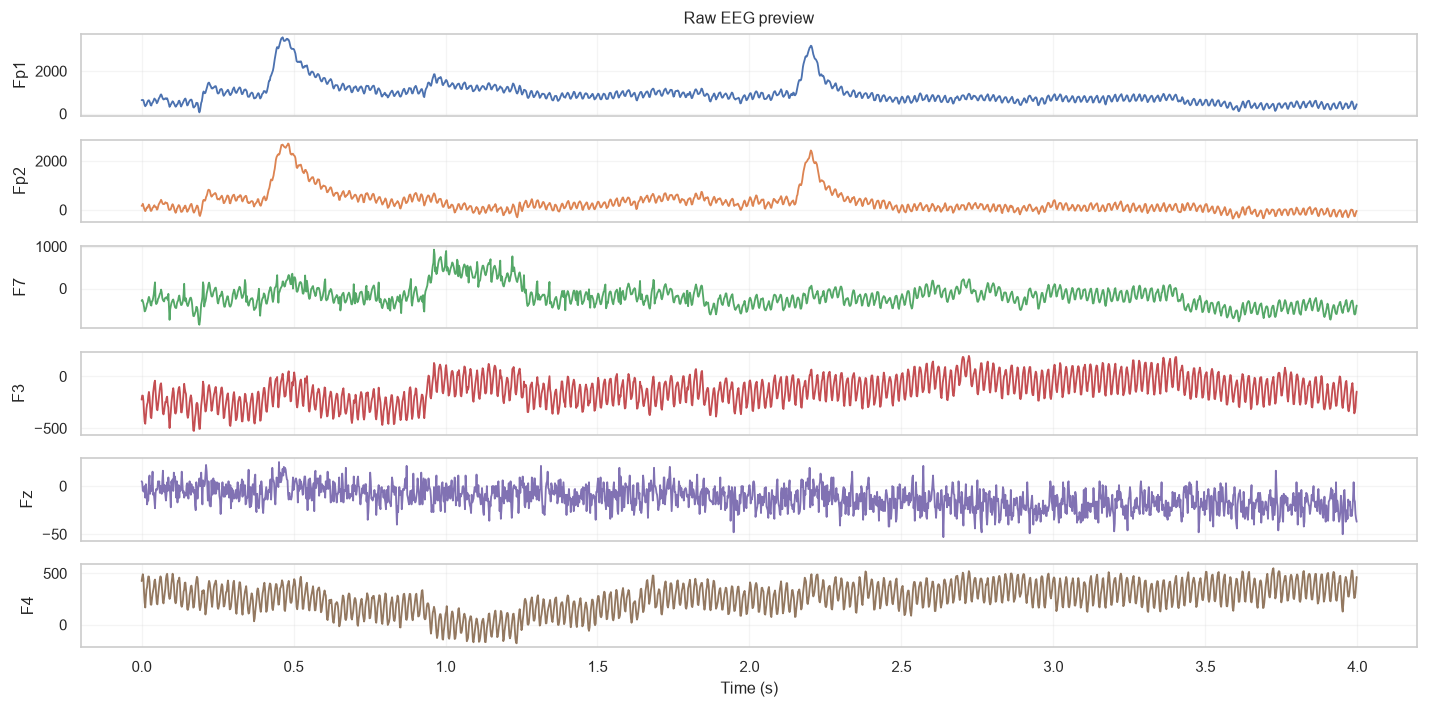

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\multichannel_raw_emg_preview.png
  results\ep50_st150_lr5e-05_bs64\plots\multichannel_raw_emg_preview.pdf


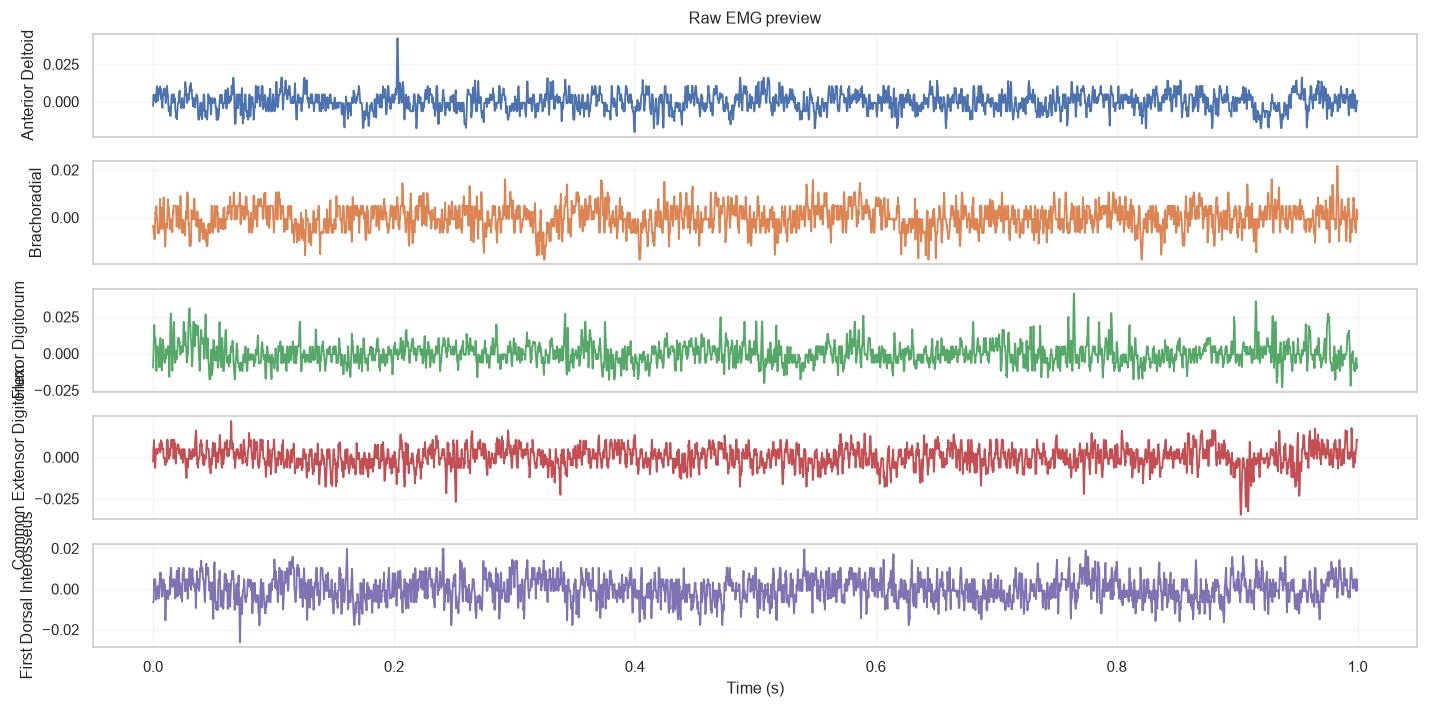

In [22]:
# @title InspectRawParticipantSeries
raw_dir = ROOT / notebook_cfg["data"]["raw_dir"]
participant = participants[0]
series_list = load_participant(raw_dir, participant=participant, file_type="hs", series=[1], include_stability=False)
series = series_list[0]

print("Participant:", series["participant"])
print("Series:", series["series"])
print("EEG shape:", series["eeg"].shape)
print("EMG shape:", series["emg"].shape)
print("Kin shape:", series["kin"].shape)

fig = plot_multichannel_trace(series["eeg"][:2000], fs=series["fs_eeg"], channel_names=series["eeg_names"], title="Raw EEG preview", max_channels=6, cfg=notebook_cfg)
plt.show()                                             
fig = plot_multichannel_trace(series["emg"][:4000], fs=series["fs_emg"], channel_names=series["emg_names"], title="Raw EMG preview", max_channels=5 , cfg=notebook_cfg)
plt.show()


Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\preprocessing_comp_eeg_ch0.png
  results\ep50_st150_lr5e-05_bs64\plots\preprocessing_comp_eeg_ch0.pdf


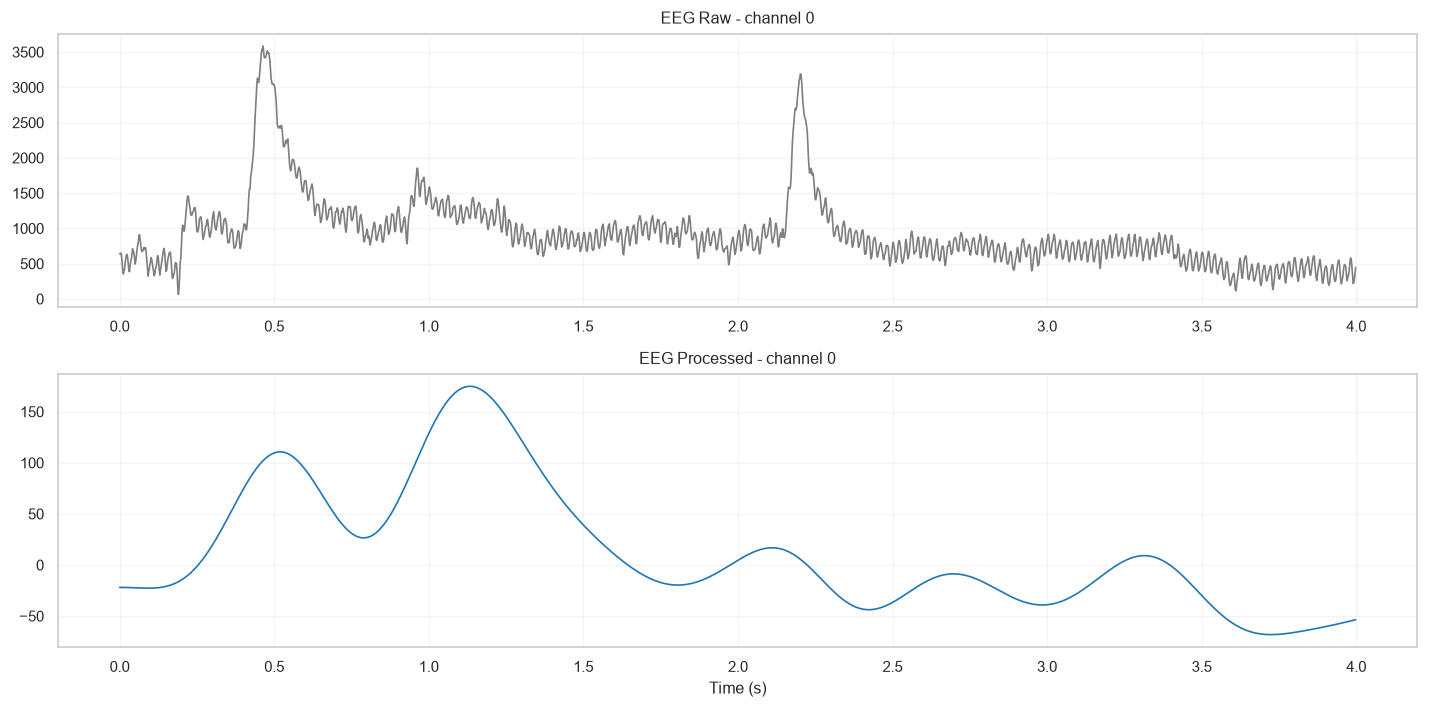

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\preprocessing_comp_emg_envelope_ch0.png
  results\ep50_st150_lr5e-05_bs64\plots\preprocessing_comp_emg_envelope_ch0.pdf


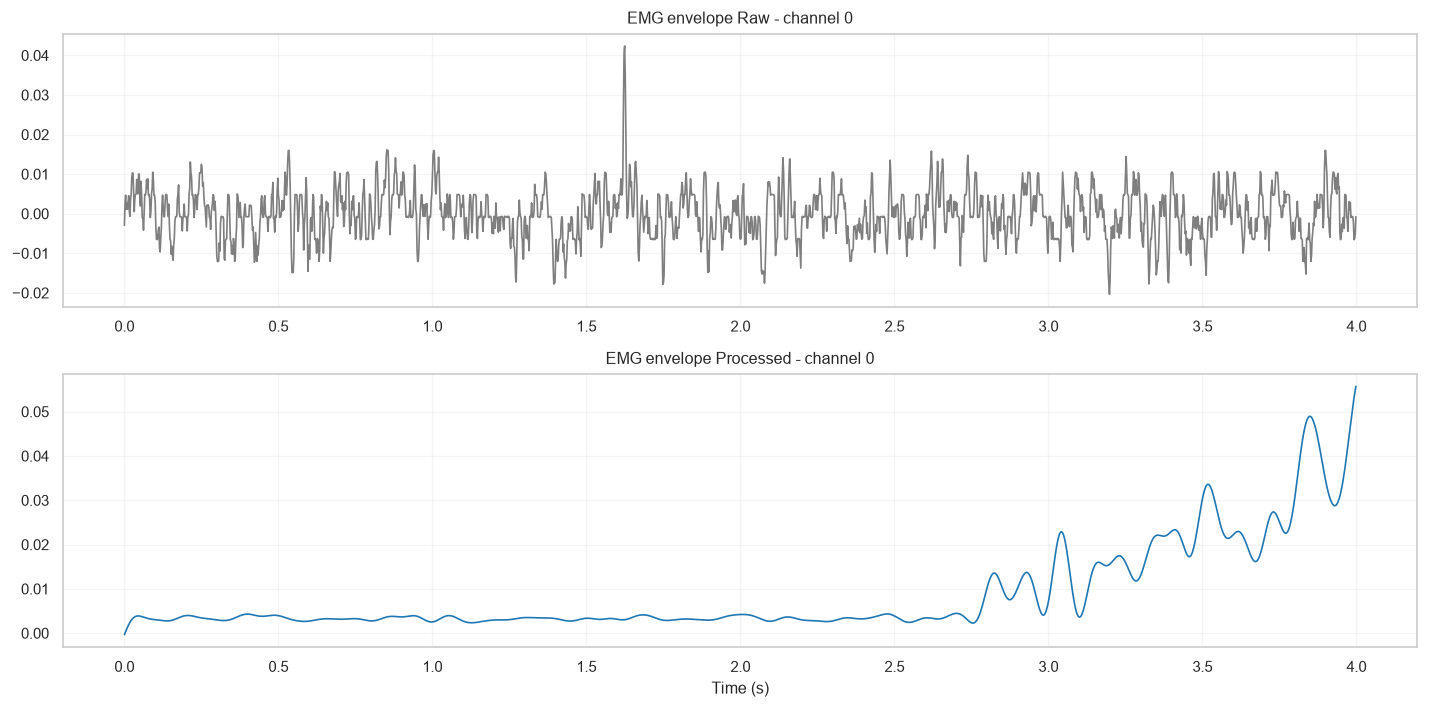

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\heatmap_processed_eeg_heatmap.png
  results\ep50_st150_lr5e-05_bs64\plots\heatmap_processed_eeg_heatmap.pdf


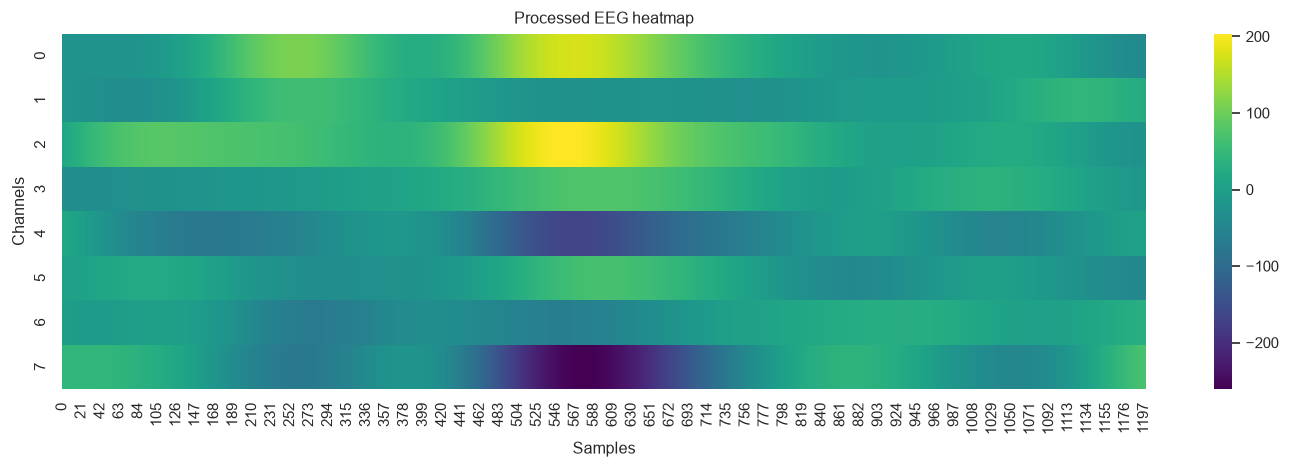

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\heatmap_processed_emg_heatmap.png
  results\ep50_st150_lr5e-05_bs64\plots\heatmap_processed_emg_heatmap.pdf


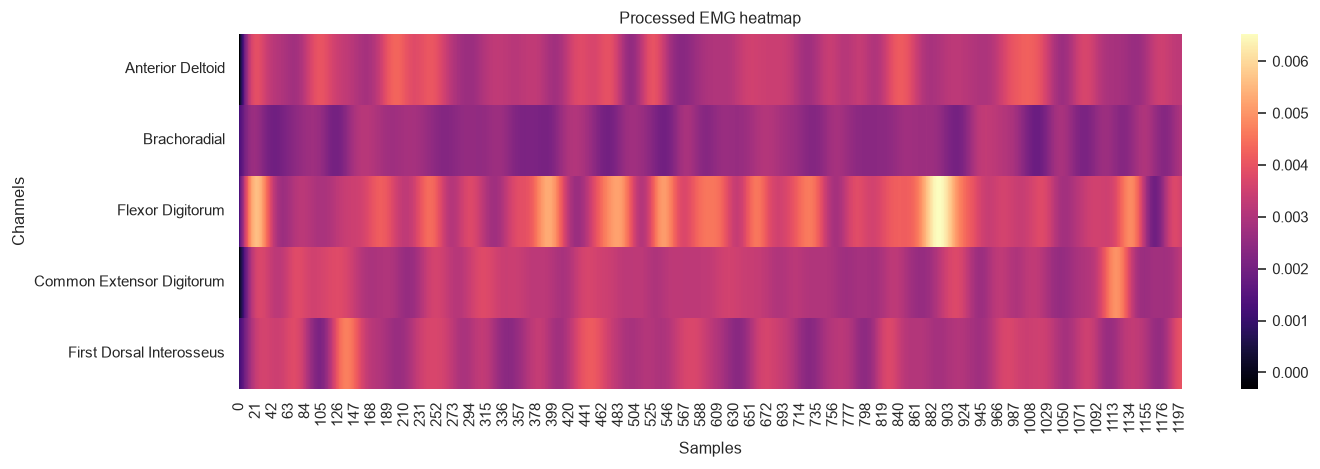

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\kinematic_features.png
  results\ep50_st150_lr5e-05_bs64\plots\kinematic_features.pdf


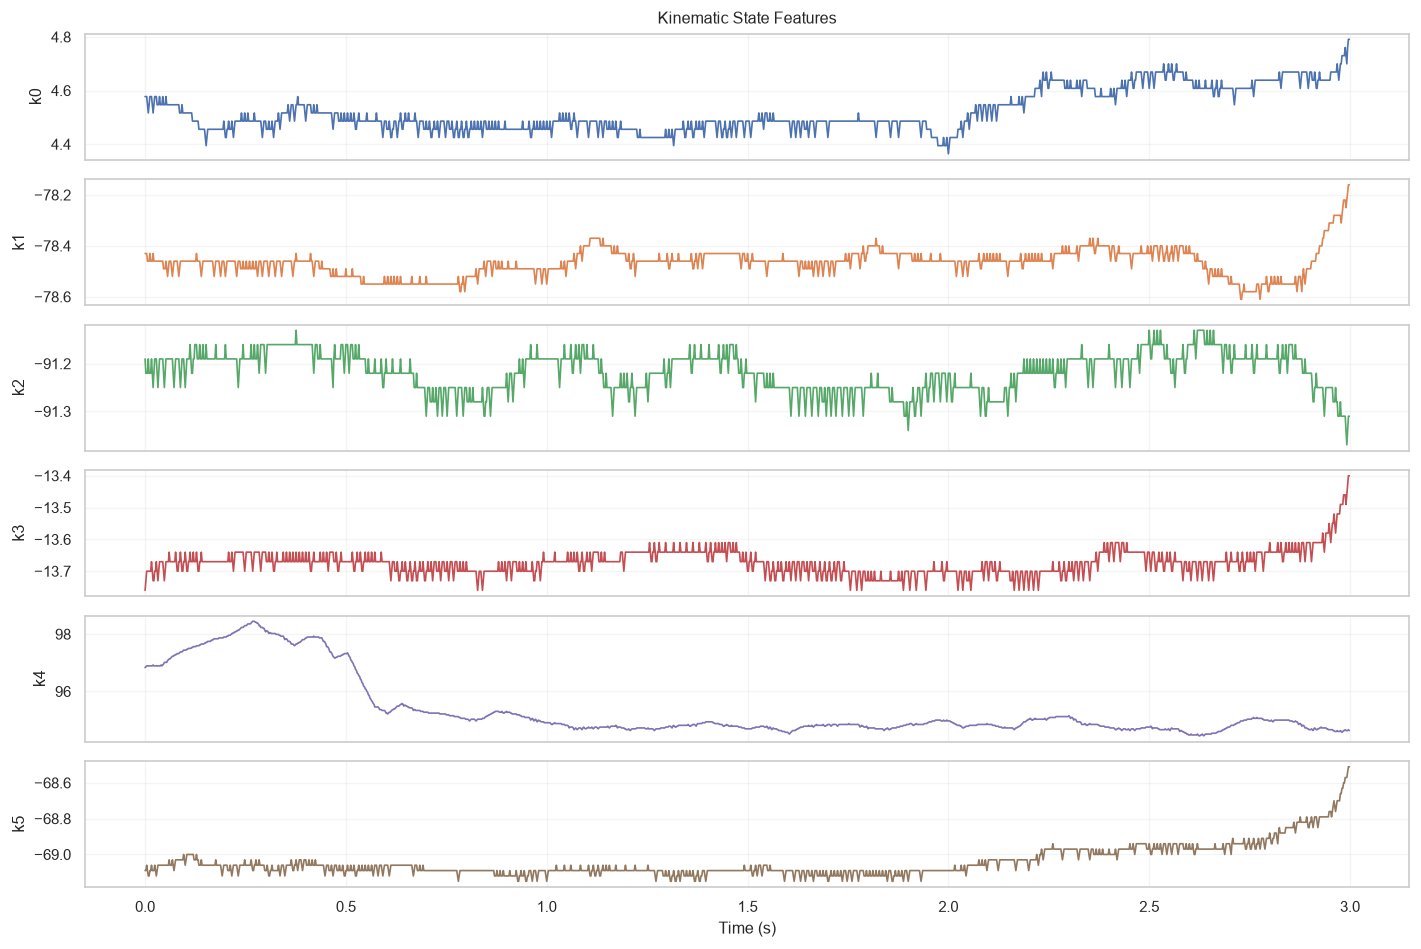

In [23]:
# @title VisualizePreprocessingPipeline
eeg_processed = preprocess_eeg_from_config(
    series["eeg"],
    fs=series["fs_eeg"],
    cfg=notebook_cfg["preprocessing"]["eeg"],
    channel_names=series["eeg_names"],
)
emg_processed = preprocess_emg_from_config(
    series["emg"],
    fs=series["fs_emg"],
    cfg=notebook_cfg["preprocessing"]["emg"],
)
kin_features = preprocess_kinematics_from_config(
    series["kin"],
    fs=series["fs_kin"],
    cfg=notebook_cfg["preprocessing"]["kinematics"],
)

fig = plot_preprocessing_comparison(                                                                       
    series["eeg"][:2000],                                                                            
    eeg_processed[:2000],                                                                            
    fs=series["fs_eeg"],                                                                             
    channel_idx=0,                                                                                   
    title_prefix="EEG",   
    cfg=notebook_cfg                                                                           
)                                                                                                    
plt.show()                                             
                                                                                                  
fig = plot_preprocessing_comparison(                                                                       
    series["emg"][:2000],                                                                            
    emg_processed[:2000],                                                                            
    fs=series["fs_eeg"],                                                                             
    channel_idx=0,                                                                                   
    title_prefix="EMG envelope",  
    cfg=notebook_cfg                                                                   
)                                                                                                    
plt.show()                                             
                   

fig = plot_signal_heatmap(                                                                                 
    eeg_processed[:1200],                                                                            
    title="Processed EEG heatmap",                                                                   
    cmap="viridis",    
    cfg=notebook_cfg                                                                              
)                                                                                                    
plt.show()                                             
                                                                                                    
fig = plot_signal_heatmap(                                                                                 
    emg_processed[:1200],                                                                            
    title="Processed EMG heatmap",                                                                   
    channel_names=series["emg_names"],                                                               
    cmap="magma",     
    cfg=notebook_cfg                                                                               
)                                                                                                    
plt.show()                                             
                                                                                                    
fig = plot_kinematic_features(                                                                             
    kin_features[:1500],                                                                             
    fs=series["fs_kin"],                                                                             
    max_features=6,      
    cfg=notebook_cfg                                                                            
)                                                                                                    
plt.show()                                             

In [24]:
# @title BuildDatasets
train_ds = build_dataset_split(notebook_cfg, participants=participants, split="train", root_dir=ROOT)
val_ds = build_dataset_split(notebook_cfg, participants=participants, split="val", root_dir=ROOT)
test_ds = build_dataset_split(notebook_cfg, participants=participants, split="test", root_dir=ROOT)

print(train_ds)
print(val_ds)
print(test_ds)

WAYEEGDataset(split='train', participants=[2], n_windows=10390, window_size=500, stride=150)
WAYEEGDataset(split='val', participants=[2], n_windows=997, window_size=500, stride=150)
WAYEEGDataset(split='test', participants=[2], n_windows=980, window_size=500, stride=150)


In [25]:
# @title Build Hybrid Model & Setup

# Grab the true dimensions
sample_eeg, sample_kin, sample_emg = train_ds[0]
true_eeg_dim = sample_eeg.shape[-1]
true_kin_dim = sample_kin.shape[-1]

model = build_model_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim, 
    kin_dim=true_kin_dim
).to(device)

loss_fn = build_loss_from_config(notebook_cfg["training"]).to(device)

# --- Compute exact dataset statistics to prevent Model Collapse ---
print("Computing dataset statistics to enforce Z-score normalization...")
_, tr_kin, tr_emg = unique_series_arrays(train_ds)

emg_concat = np.concatenate(tr_emg, axis=0)
emg_mean_tensor = torch.tensor(emg_concat.mean(0), dtype=torch.float32, device=device)
emg_std_tensor = torch.tensor(emg_concat.std(0) + 1e-8, dtype=torch.float32, device=device)

kin_concat = np.concatenate(tr_kin, axis=0)
kin_mean_tensor = torch.tensor(kin_concat.mean(0), dtype=torch.float32, device=device)
kin_std_tensor = torch.tensor(kin_concat.std(0) + 1e-8, dtype=torch.float32, device=device)

# Prepare batch WITH the true scaling tensors
prepare_batch = prepare_batch_factory(
    emg_mean=emg_mean_tensor,
    emg_std=emg_std_tensor,
    kin_mean=kin_mean_tensor,
    kin_std=kin_std_tensor,
    device=device
)

print(f"Model configured for {true_eeg_dim} EEG channels and {true_kin_dim} KIN channels.")
print("Model Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Computing dataset statistics to enforce Z-score normalization...
Model configured for 8 EEG channels and 13 KIN channels.
Model Parameters: 532282


In [26]:
# @title Setup Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=device.type == "cuda"
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=device.type == "cuda"
)


In [27]:
# @title Train Hybrid Model via K-Fold Cross Validation

all_fold_results, save_folder = run_kfold_cross_validation(
    notebook_cfg=notebook_cfg,
    train_ds=train_ds,          # Your full training dataset object
    batch_size=batch_size,      # E.g., 32 or 64 from your earlier cell
    prepare_batch=prepare_batch,# Your scaling factory
    loss_fn=loss_fn,            # e.g., nn.MSELoss()
    device=device,
    train_model_func=train_model, # The framework's standard training loop 
    resume = True,
    smoke_run=False,        # If True, trains 1 epoch. If False, uses max_epochs from config
    k_folds=5                   # Standard 5-fold split
)

print(f"\nSuccess! All K-Fold assets, checkpoints, and plots are inside: {save_folder}")


Results and Checkpoints will be saved to: results\ep50_st150_lr5e-05_bs64


K-Fold Progress:   0%|          | 0/5 [00:00<?, ?it/s]

INFO | Training on cuda | AMP=False | epochs=50 | lr=5e-05 | ckpt_dir=results\ep50_st150_lr5e-05_bs64\fold_1\checkpoints


  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 4.1 MB
  OK  VRAM reserved   : 6.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active

Starting fresh training run  (checkpoint_dir=results\ep50_st150_lr5e-05_bs64\fold_1\checkpoints)



  Ep    1 [train]:   0%|          | 0/129 [00:00<?, ?batch/s]

...

INFO | Ep   49/50 | train 0.2542 | val 0.3119 | lr 5.00e-05 |  52.0s | VRAM 43/6144 MB  <- BEST


  Ep   50 [train]:   0%|          | 0/129 [00:00<?, ?batch/s]

  Ep   50 [val  ]:   0%|          | 0/33 [00:00<?, ?batch/s]

INFO | Ep   50/50 | train 0.2536 | val 0.3091 | lr 5.00e-05 |  52.2s | VRAM 43/6144 MB  <- BEST



Training done.  Best val loss = 0.3091
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\notebooks\results\ep50_st150_lr5e-05_bs64\fold_5\checkpoints

All 5 Folds Completed! Checkpoints saved in: results\ep50_st150_lr5e-05_bs64

Success! All K-Fold assets, checkpoints, and plots are inside: results\ep50_st150_lr5e-05_bs64


In [253]:
# # @title Train Hybrid Model
# train_cfg = TrainConfig.from_config(
#     notebook_cfg["training"], 
#     max_epochs=max_epochs if smoke_run else notebook_cfg["training"]["max_epochs"]
# )

# if not hasattr(train_cfg, "checkpoint_dir") or train_cfg.checkpoint_dir is None:
#     train_cfg.checkpoint_dir = "data/cache/checkpoints"

# # FIX: Explicitly disable AMP (FP16) to prevent NaN overflow!
# train_cfg.use_amp = False

# result = train_model(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     prepare_batch=prepare_batch,
#     loss_fn=loss_fn,
#     device=device,
#     cfg=train_cfg, 
#     resume=False,
# )

Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\training_history.png
  results\ep50_st150_lr5e-05_bs64\plots\training_history.pdf


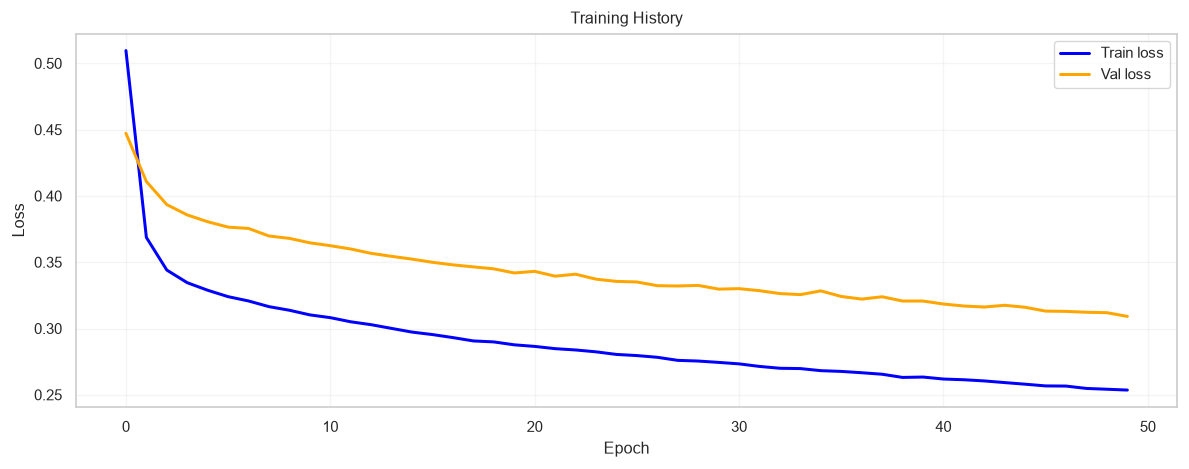

In [29]:
# @title Plot Loss Curve

# Let's plot Fold 1 (index 0)
fold_index = 4
fold_result = all_fold_results[fold_index]

fig_loss = plot_training_history(fold_result.history, cfg=notebook_cfg)

In [32]:
def get_checkpoint_path(cfg, fold_idx):
    """Dynamically reconstructs the path to best.pt for any given fold."""
    max_epochs = cfg["training"]["max_epochs"]
    stride = cfg["data"]["stride"]
    lr = cfg["training"].get("lr", 1e-4)
    bs = cfg["training"]["batch_size"]
    config_str = f"ep{max_epochs}_st{stride}_lr{lr}_bs{bs}"
    
    return Path("results") / config_str / f"fold_{fold_idx + 1}" / "checkpoints" / "best.pt"

In [33]:
# @title Extract Attention Weights

# 1. Build a fresh base model
sample_eeg, sample_kin, _ = test_ds[0]
model = build_model_from_config(
    notebook_cfg, 
    input_dim=sample_eeg.shape[-1], 
    kin_dim=sample_kin.shape[-1]
).to(device)

# --- LOAD SAFELY FROM THE HARD DRIVE INSTEAD OF RAM ---
# Let's load Fold 4 (index 3) since you were looking at that one!
checkpoint_path = get_checkpoint_path(notebook_cfg, fold_idx=3) 
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Successfully loaded checkpoint from: {checkpoint_path.parent.parent.name}")

# 2. Grab a single batch from the test loader
for batch in test_loader:
    eeg_batch, kin_batch, emg_batch = batch
    model_inputs, emg_targets = prepare_batch(eeg_batch, kin_batch, emg_batch)
    break

# 3. Forward pass requesting the attention weights
with torch.no_grad():
    preds, interpret_dict = model(
        model_inputs["eeg"], 
        model_inputs["kin"], 
        return_attention=True
    )
print("Attention weights & Fused variables successfully extracted!")

Successfully loaded checkpoint from: fold_4
Attention weights & Fused variables successfully extracted!


Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\gate_heatmap.png
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\gate_heatmap.pdf
Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\eeg_to_kin_cross_attention_mean.png
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\eeg_to_kin_cross_attention_mean.pdf
Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\eeg_to_kin_cross_attention_per_head.png
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\eeg_to_kin_cross_attention_per_head.pdf
Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\kin_to_eeg_cross_attention_mean.png
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\kin_to_eeg_cross_attention_mean.pdf
Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\kin_to_eeg_cross_attention_per_head.png
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\kin_to_eeg_cross_attention_per_head.pdf
Saved figure:
  results\ep50_st150_lr5e-05_bs64\fold_5\plots\self_attention_final_layer_mean.png
  results\ep50_st150_lr5e

(<Figure size 720x600 with 2 Axes>, <Figure size 1680x720 with 8 Axes>)

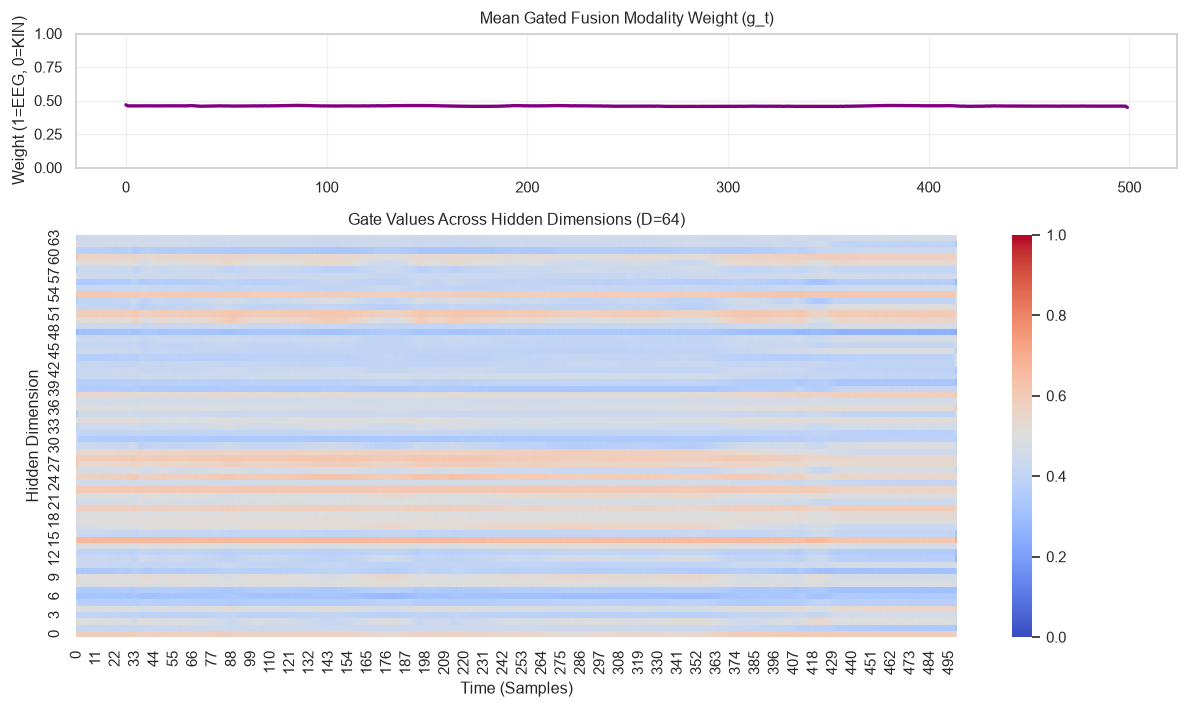

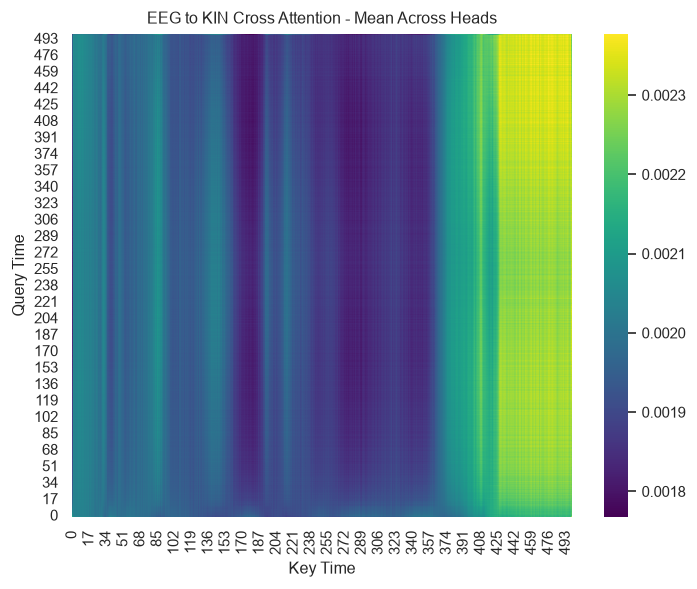

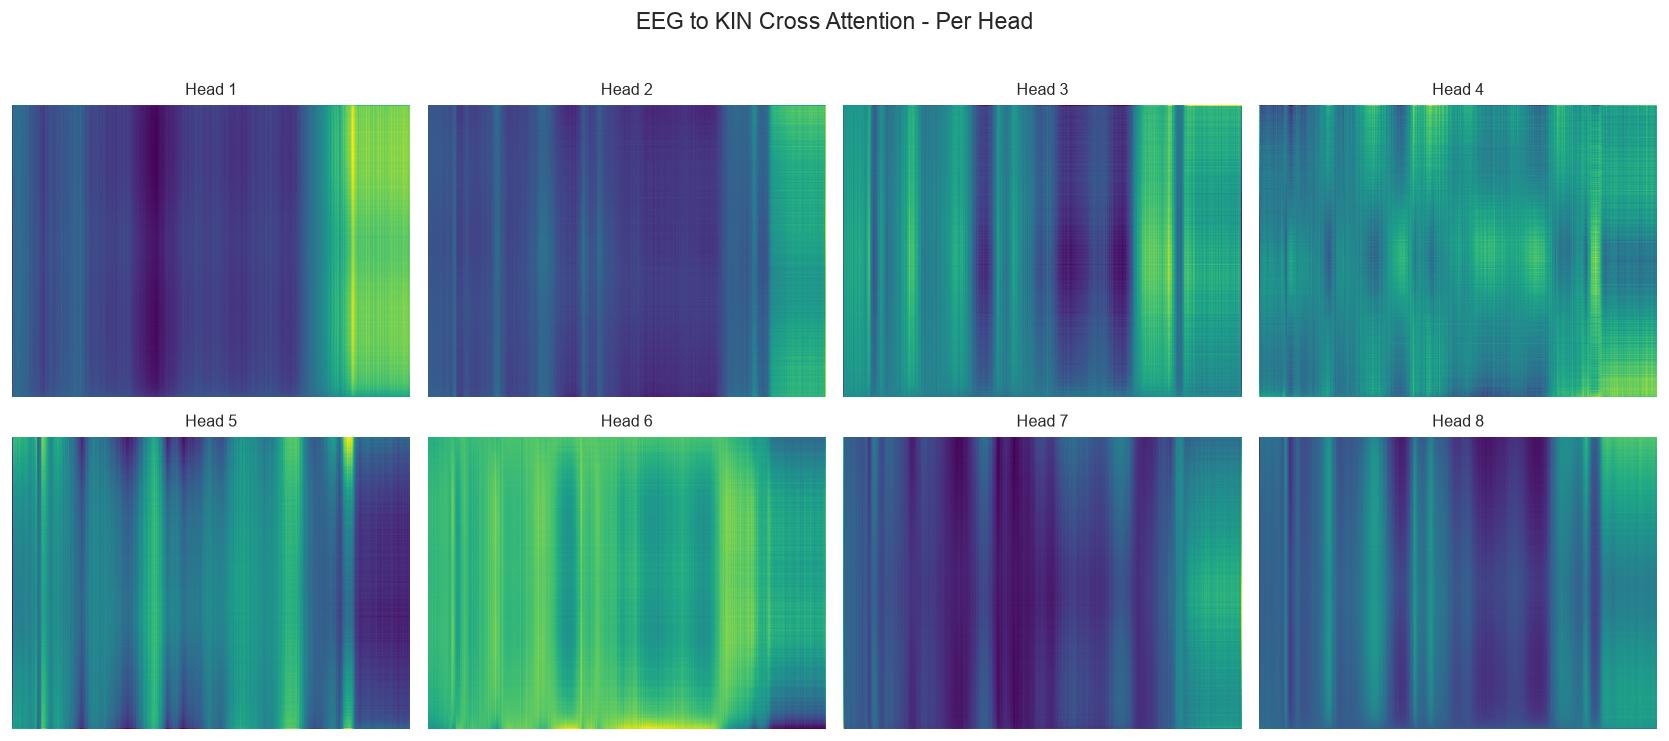

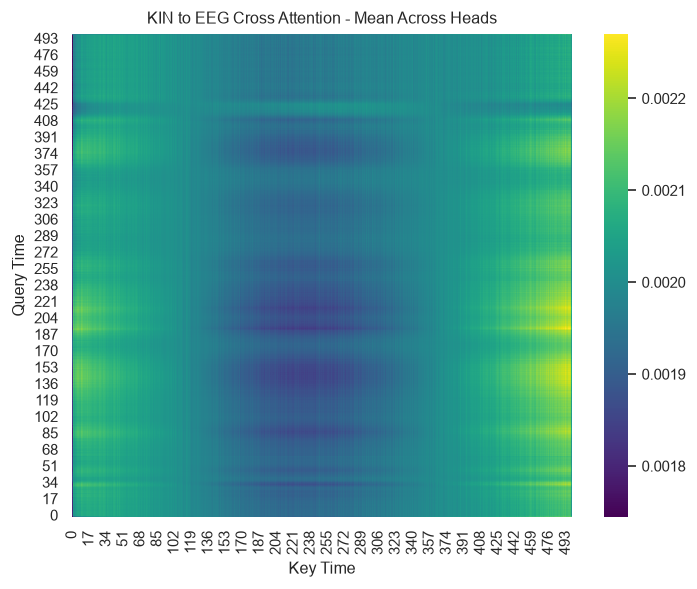

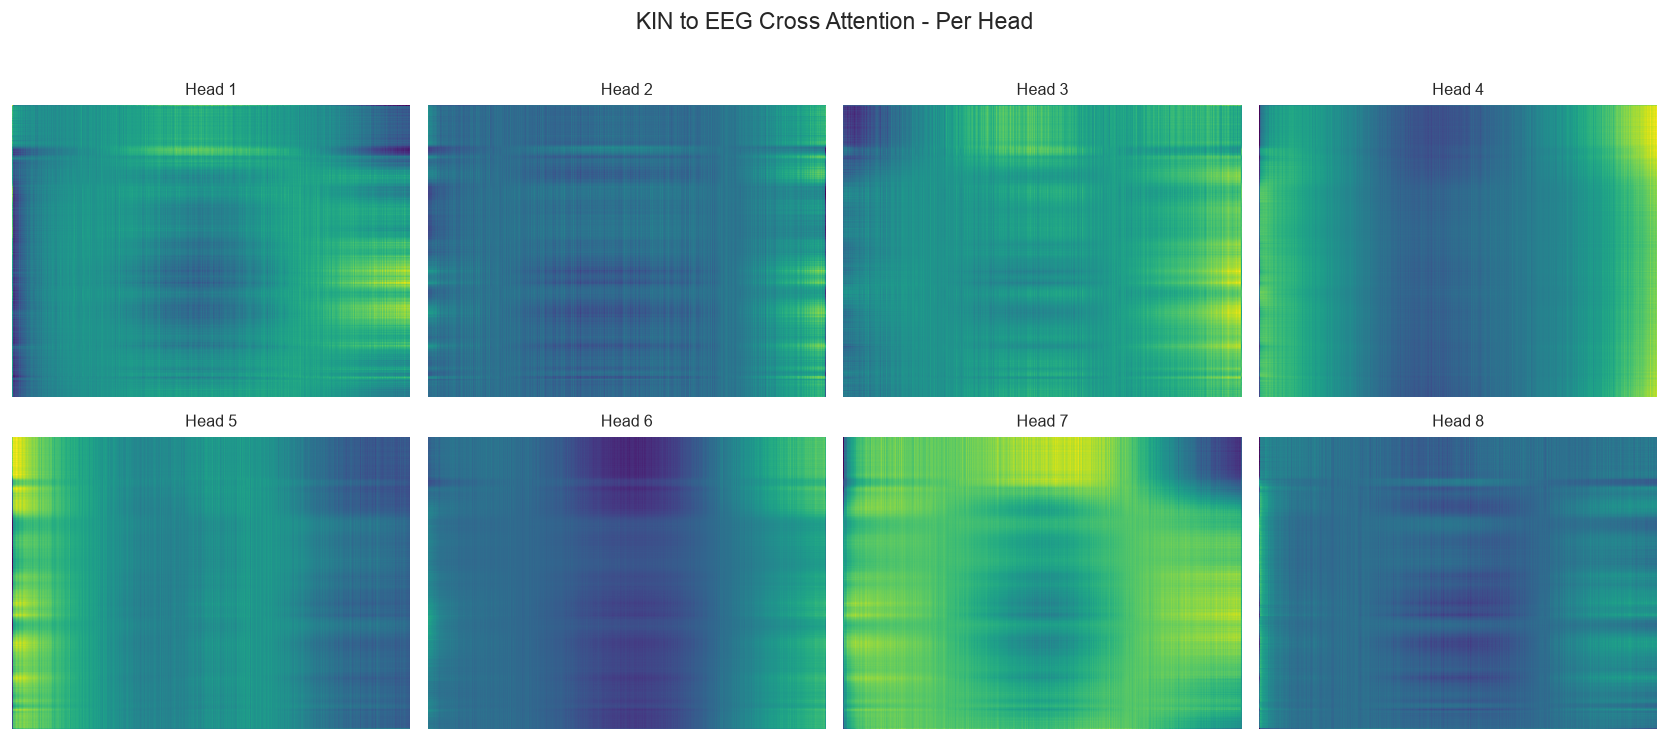

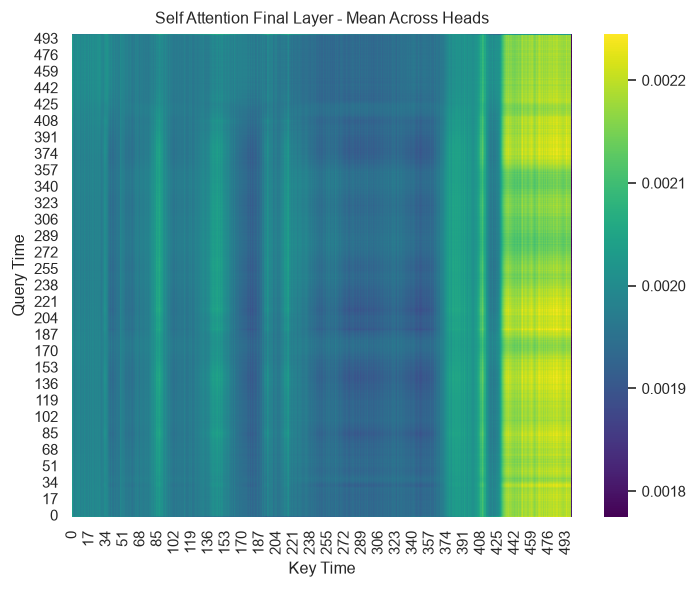

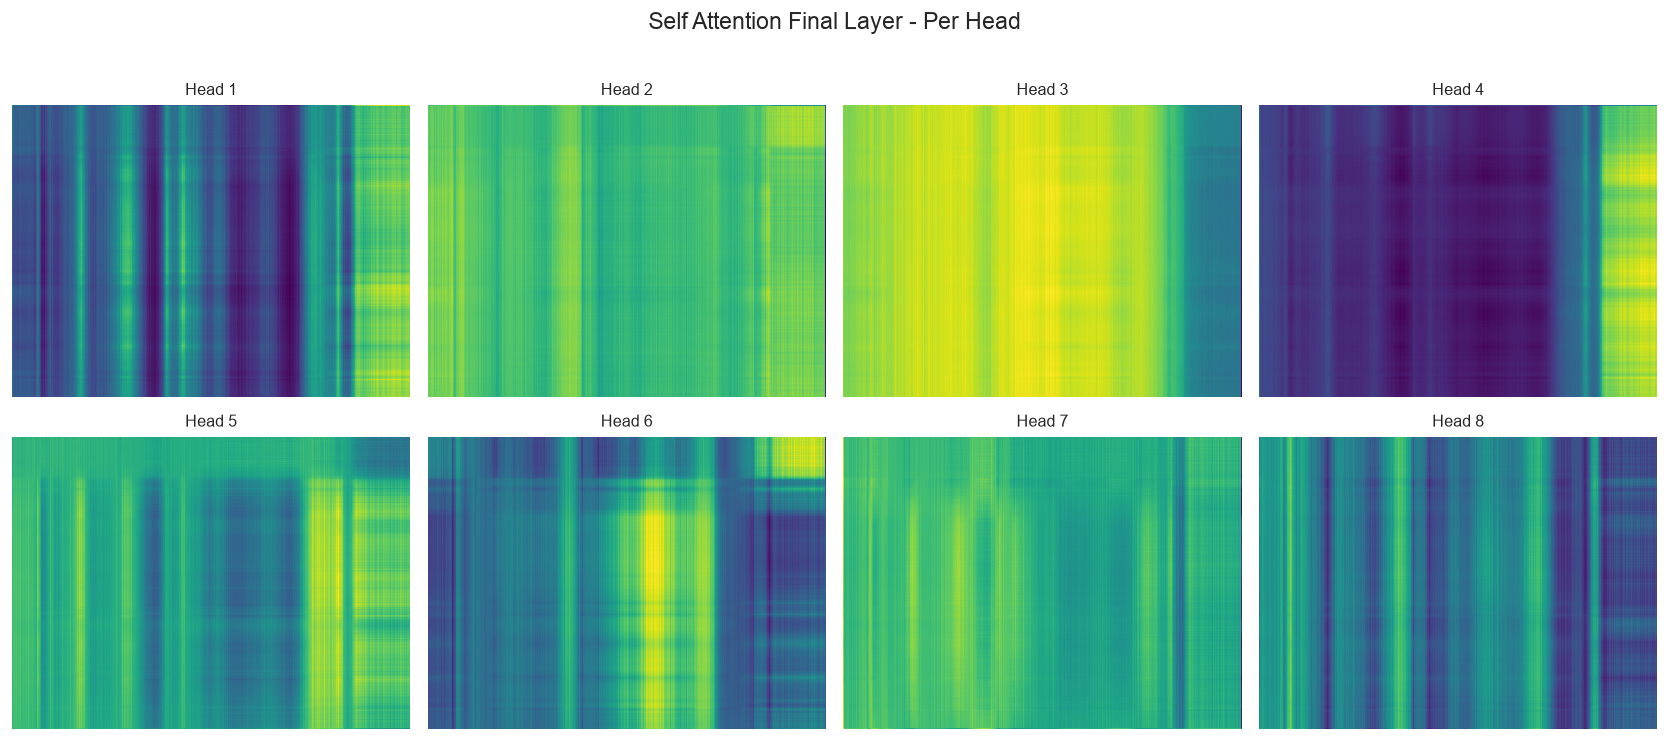

In [38]:
# @titlePlot Gate and Attention Maps

# Plot the Gated Fusion Heatmap
plot_gate_heatmap(interpret_dict["gate"], sample_idx=0, cfg=notebook_cfg)

# Plot Dual Cross-Attention
plot_attention_maps(interpret_dict["cross_attn_eeg_kin"], "EEG to KIN Cross Attention", cfg=notebook_cfg)
plot_attention_maps(interpret_dict["cross_attn_kin_eeg"], "KIN to EEG Cross Attention", cfg=notebook_cfg)

# Plot Self-Attention (Final Layer = -1)
plot_attention_maps(interpret_dict["self_attn"][-1], "Self Attention Final Layer", cfg=notebook_cfg)


--- Test Set Evaluation Metrics ---
            channel     RMSE      MAE  Pearson
       Ant. Deltoid 0.012063 0.008542 0.868348
    Ext. Carpi Rad. 0.005825 0.004419 0.838677
    Flex. Digitorum 0.002195 0.001506 0.760784
    Ext. Dig. Comm. 0.004068 0.002982 0.916584
1st Dors. Inteross. 0.007536 0.003804 0.791332
                    0.006338 0.004251 0.835145

Saving and Plotting Continuous Trajectories...
Saved figure:
  results\ep50_st150_lr5e-05_bs64\plots\prediction_overlay.png
  results\ep50_st150_lr5e-05_bs64\plots\prediction_overlay.pdf


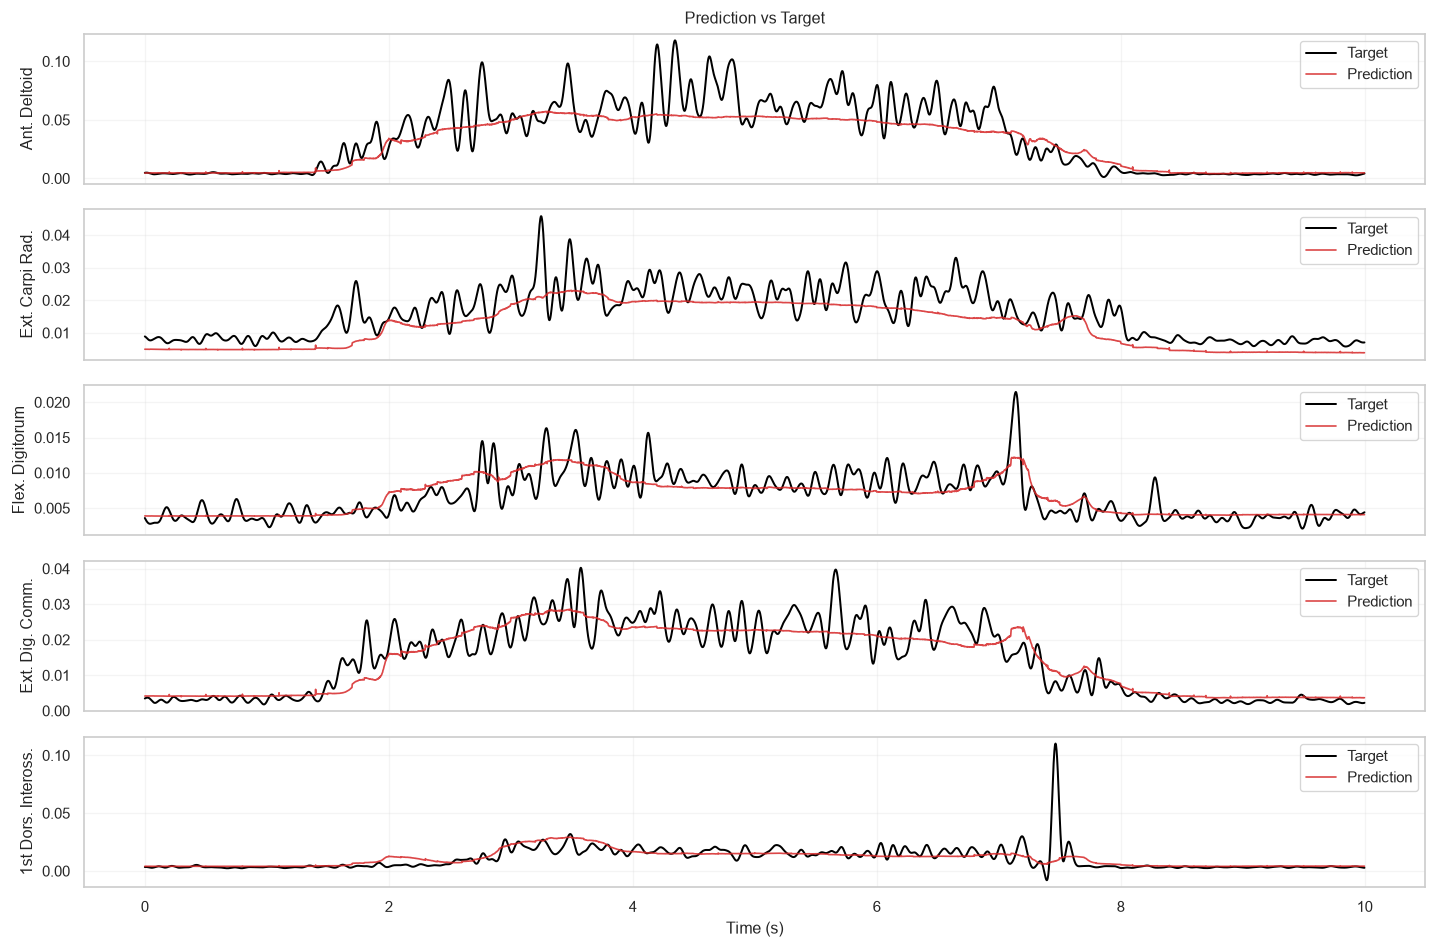

In [35]:
# @titleContinuous Evaluation & Prediction Overlay

# 1. Predict the full overlapping sequence from the Test Dataset
pred_full, target_full = predict_full_series_from_dataset(
    model=model,
    ds=test_ds,
    prepare_batch=prepare_batch,
    emg_mean=emg_mean_tensor, # Using the stats we calculated before training
    emg_std=emg_std_tensor,
    device=device,
    series_idx=0, 
)

# 2. Compute Benchmark Metrics on the continuous prediction
metrics = []
for c in range(5):
    p = pred_full[:, c]
    t = target_full[:, c]
    rmse = np.sqrt(np.mean((p - t)**2))
    mae = np.mean(np.abs(p - t))
    corr, _ = pearsonr(p, t)
    metrics.append({"channel": EMG_CHANNEL_NAMES[c], "RMSE": rmse, "MAE": mae, "Pearson": corr})

df_metrics = pd.DataFrame(metrics)
df_metrics.loc["MEAN"] = df_metrics.mean(numeric_only=True)
df_metrics.fillna("", inplace=True)
print("\n--- Test Set Evaluation Metrics ---")
print(df_metrics.to_string(index=False))

# 3. Plot a specific time slice (e.g., sample 5000 to 10000 = 10 seconds at 500Hz)
start_idx = 5000 
end_idx = 10000 

print("\nSaving and Plotting Continuous Trajectories...")
plot_prediction_overlay(
    pred=pred_full[start_idx:end_idx], 
    target=target_full[start_idx:end_idx], 
    fs=500, 
    channel_names=EMG_CHANNEL_NAMES, 
    cfg=notebook_cfg
);


Running rigorous K-Fold evaluation across all models...
Evaluating Fold 1/5...
Evaluating Fold 2/5...
Evaluating Fold 3/5...
Evaluating Fold 4/5...
Evaluating Fold 5/5...

------------------------------------------------------------
 FINAL K-FOLD SCIENTIFIC BENCHMARK (Mean ± Std)
------------------------------------------------------------
            Channel          RMSE           MAE       Pearson
       Ant. Deltoid 0.012 ± 0.000 0.008 ± 0.000 0.870 ± 0.002
    Ext. Carpi Rad. 0.006 ± 0.000 0.004 ± 0.000 0.839 ± 0.001
    Flex. Digitorum 0.002 ± 0.000 0.001 ± 0.000 0.761 ± 0.004
    Ext. Dig. Comm. 0.004 ± 0.000 0.003 ± 0.000 0.914 ± 0.002
1st Dors. Inteross. 0.007 ± 0.000 0.004 ± 0.000 0.798 ± 0.004
       OVERALL MEAN 0.006 ± 0.003 0.004 ± 0.002 0.836 ± 0.055

Raw test metrics successfully saved to: results\ep50_st150_lr5e-05_bs64\kfold_test_metrics.csv

Saving and Plotting Continuous Trajectories for ALL Folds...
Plotting fold_1...
Saved figure:
  results\ep50_st150_lr5e-05_bs64

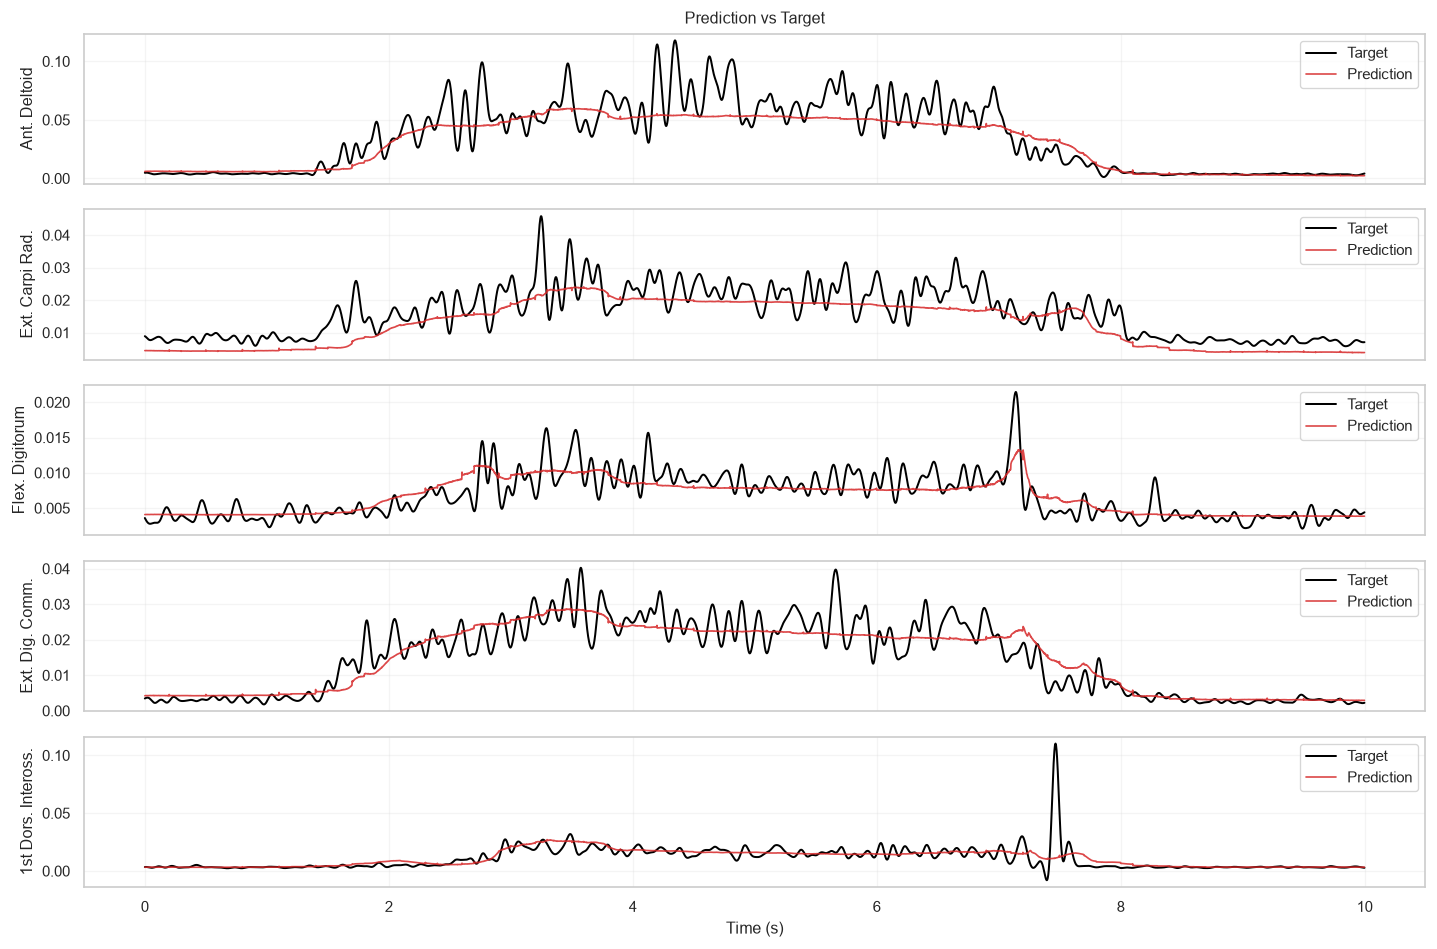

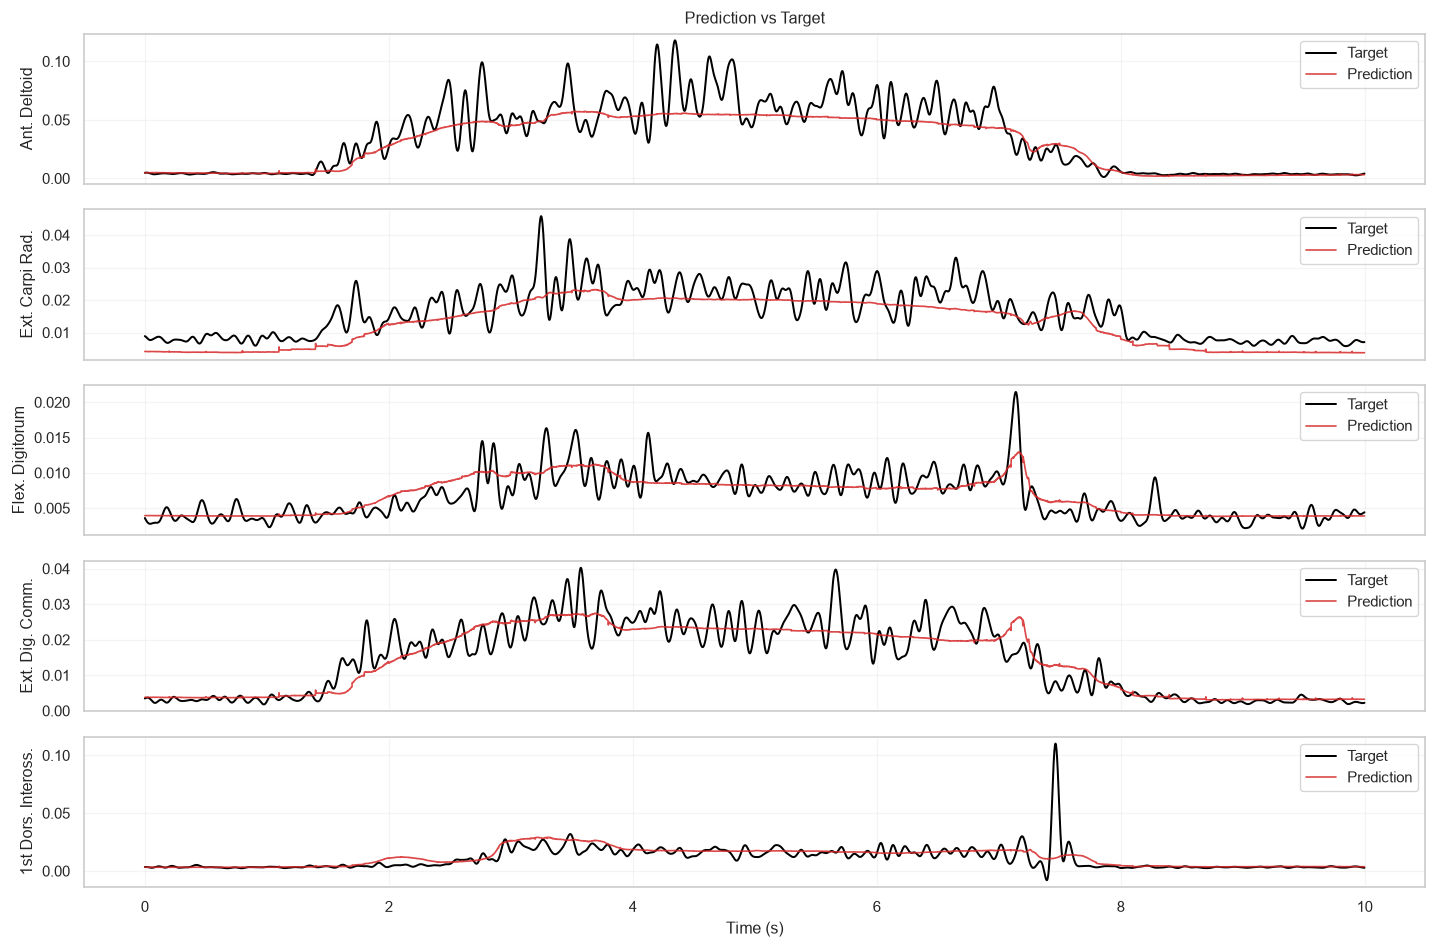

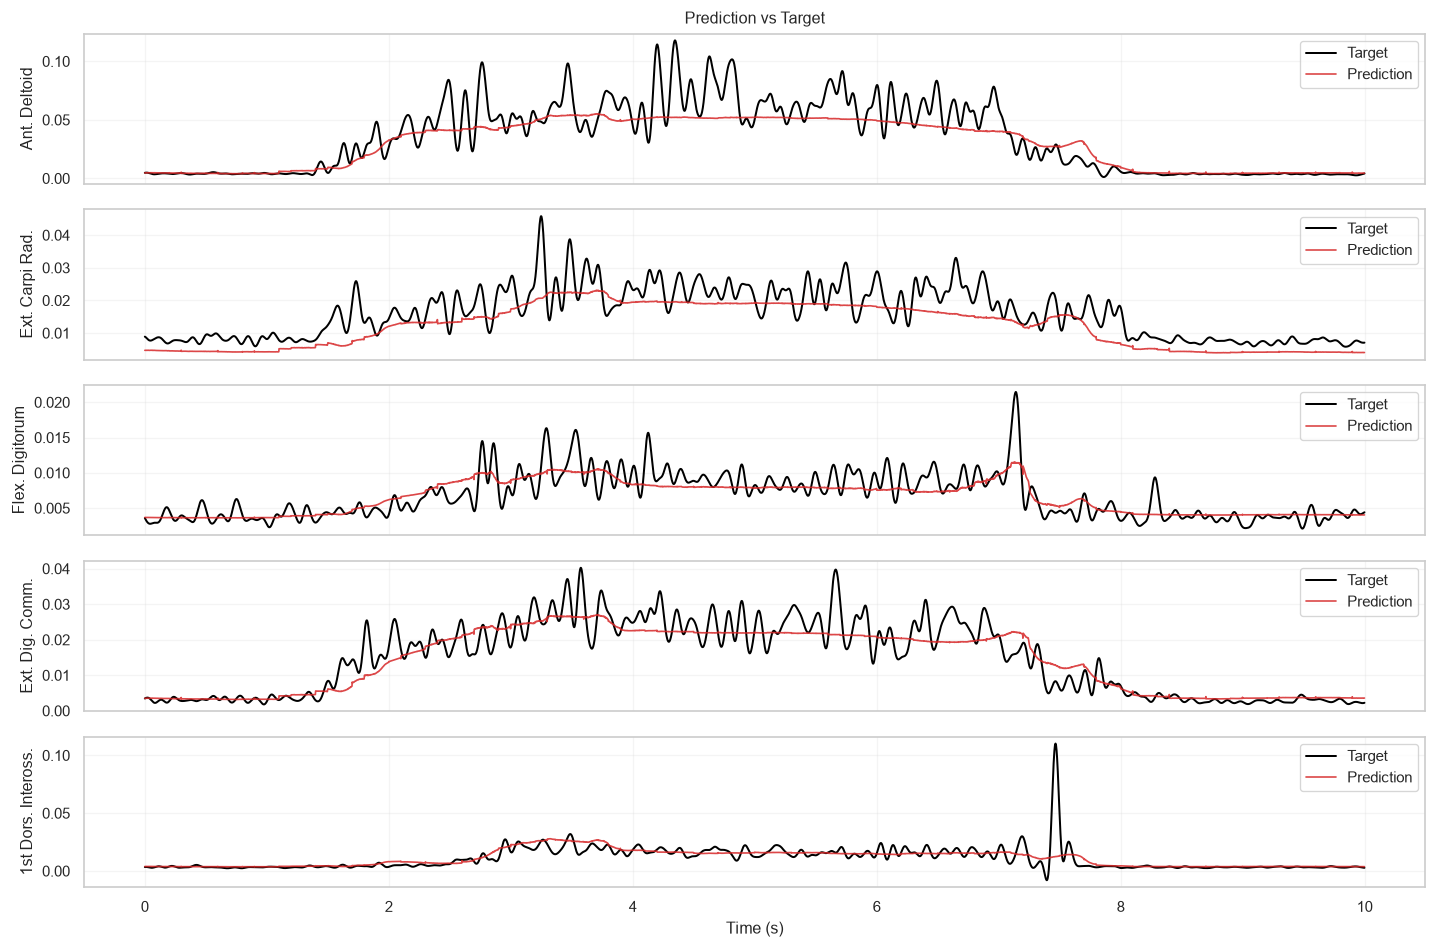

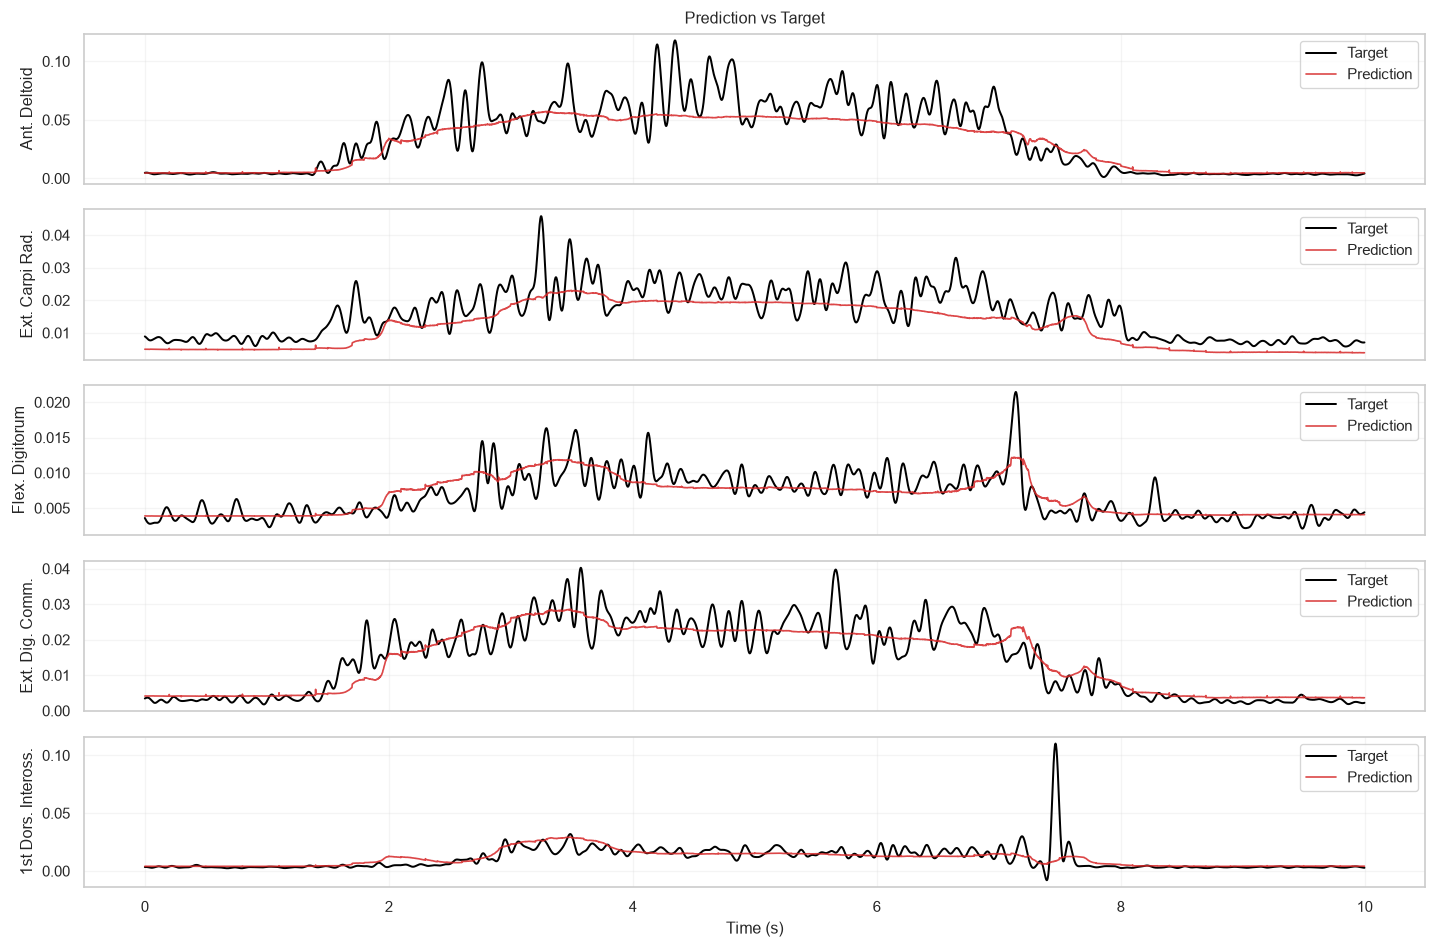

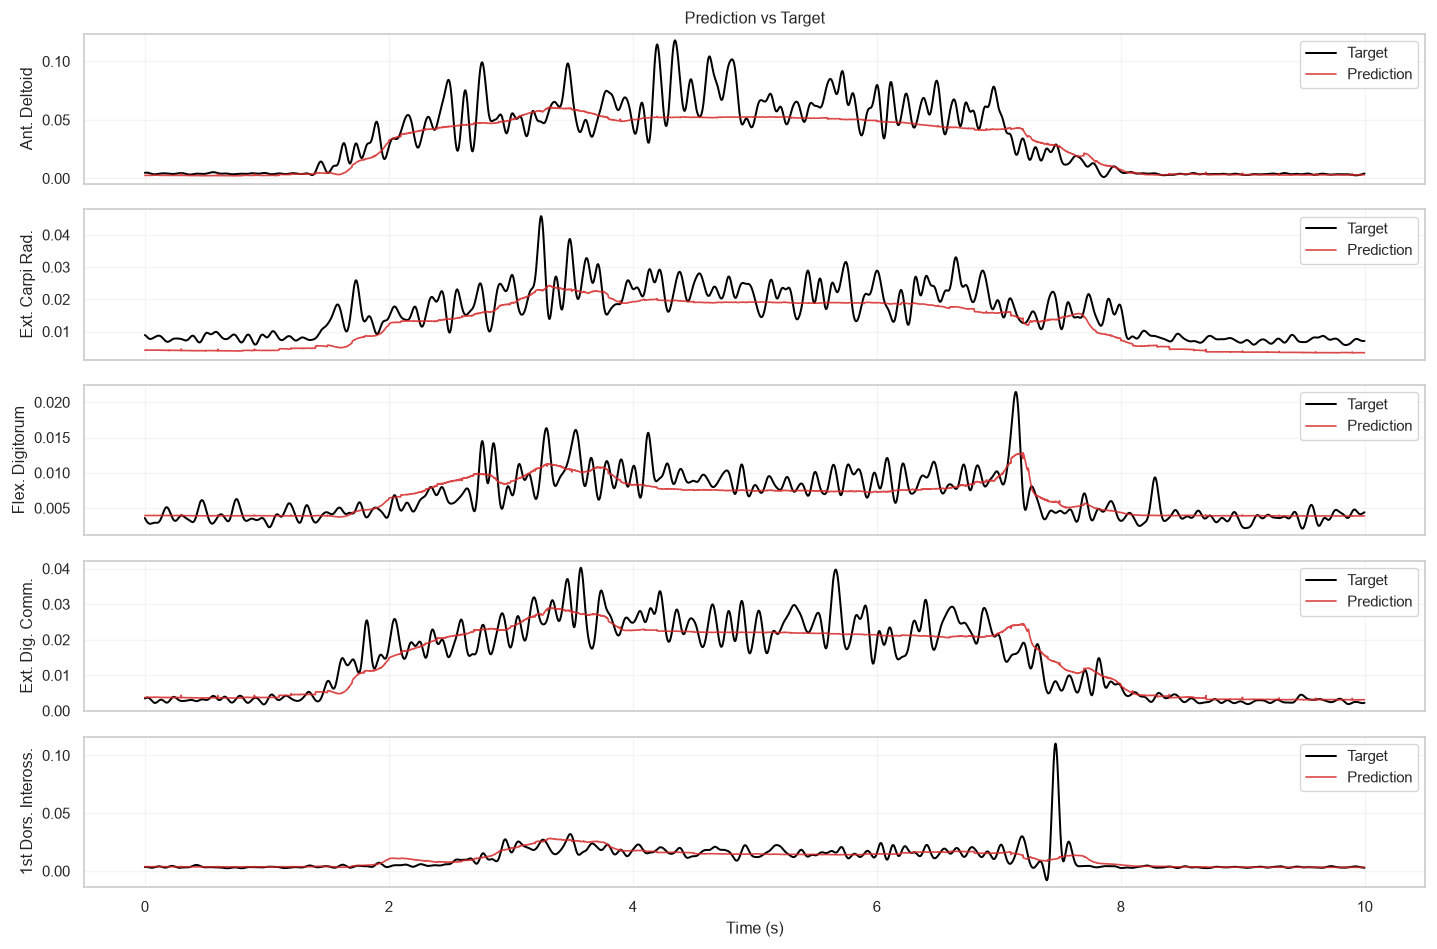

In [36]:
# @title Rigorous K-Fold Continuous Evaluation

print("Running rigorous K-Fold evaluation across all models...")

# Ensure we have a fresh base model in memory
sample_eeg, sample_kin, _ = test_ds[0]
model = build_model_from_config(notebook_cfg, input_dim=sample_eeg.shape[-1], kin_dim=sample_kin.shape[-1]).to(device)

# Initialize storage for our metrics and predictions
k_fold_metrics = []
all_predictions = {}   
all_targets = {}       

for fold_idx, res in enumerate(all_fold_results):
    print(f"Evaluating Fold {fold_idx + 1}/{len(all_fold_results)}...")
    
    # 1. Load the full checkpoint dictionary from the hard drive
    checkpoint_path = get_checkpoint_path(notebook_cfg, fold_idx)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract JUST the model weights from the dictionary and load them
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    
    # 2. Predict the full continuous sequence
    pred_full, target_full = predict_full_series_from_dataset(
        model=model,
        ds=test_ds,
        prepare_batch=prepare_batch,
        emg_mean=emg_mean_tensor,
        emg_std=emg_std_tensor,
        device=device,
        series_idx=0, 
    )
    all_predictions[f"fold_{fold_idx + 1}"] = pred_full.copy()
    all_targets[f"fold_{fold_idx + 1}"] = target_full.copy()
    
    # 3. Calculate metrics for each of the 5 channels
    for c in range(5):
        p = pred_full[:, c]
        t = target_full[:, c]
        
        rmse = np.sqrt(np.mean((p - t)**2))
        mae = np.mean(np.abs(p - t))
        corr, _ = pearsonr(p, t)
        
        k_fold_metrics.append({
            "Fold": fold_idx + 1,
            "Channel": EMG_CHANNEL_NAMES[c],
            "RMSE": rmse,
            "MAE": mae,
            "Pearson": corr
        })

# Convert to DataFrame for easy analysis
df_all = pd.DataFrame(k_fold_metrics)

# Calculate Mean and Std Deviation across folds for each channel
summary_rows = []
for channel in EMG_CHANNEL_NAMES:
    ch_data = df_all[df_all["Channel"] == channel]
    summary_rows.append({
        "Channel": channel,
        "RMSE": f"{ch_data['RMSE'].mean():.3f} ± {ch_data['RMSE'].std():.3f}",
        "MAE": f"{ch_data['MAE'].mean():.3f} ± {ch_data['MAE'].std():.3f}",
        "Pearson": f"{ch_data['Pearson'].mean():.3f} ± {ch_data['Pearson'].std():.3f}"
    })

df_summary = pd.DataFrame(summary_rows)

# Calculate the Grand Mean across everything
overall_rmse_mean = df_all['RMSE'].mean()
overall_rmse_std = df_all['RMSE'].std()
overall_mae_mean = df_all['MAE'].mean()
overall_mae_std = df_all['MAE'].std()
overall_pearson_mean = df_all['Pearson'].mean()
overall_pearson_std = df_all['Pearson'].std()

# Add the final TOTAL row
df_summary.loc[len(df_summary)] = {
    "Channel": "OVERALL MEAN",
    "RMSE": f"{overall_rmse_mean:.3f} ± {overall_rmse_std:.3f}",
    "MAE": f"{overall_mae_mean:.3f} ± {overall_mae_std:.3f}",
    "Pearson": f"{overall_pearson_mean:.3f} ± {overall_pearson_std:.3f}"
}

print("\n" + "-"*60)
print(" FINAL K-FOLD SCIENTIFIC BENCHMARK (Mean ± Std)")
print("-"*60)
print(df_summary.to_string(index=False))

# Save the raw data to your config folder!
csv_path = checkpoint_path.parent.parent.parent / "kfold_test_metrics.csv"
df_all.to_csv(csv_path, index=False)
print(f"\nRaw test metrics successfully saved to: {csv_path}")

start_idx = 5000 
end_idx = 10000 

print("\nSaving and Plotting Continuous Trajectories for ALL Folds...")

for fold_name in all_predictions.keys():
    print(f"Plotting {fold_name}...")
    
    notebook_cfg["training"]["current_fold"] = fold_name
    
    plot_prediction_overlay(
        pred=all_predictions[fold_name][start_idx:end_idx], 
        target=all_targets[fold_name][start_idx:end_idx], 
        fs=500, 
        channel_names=EMG_CHANNEL_NAMES, 
        cfg=notebook_cfg
    )

Saved figure:
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\residual_diagnostics_ch0.png
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\residual_diagnostics_ch0.pdf


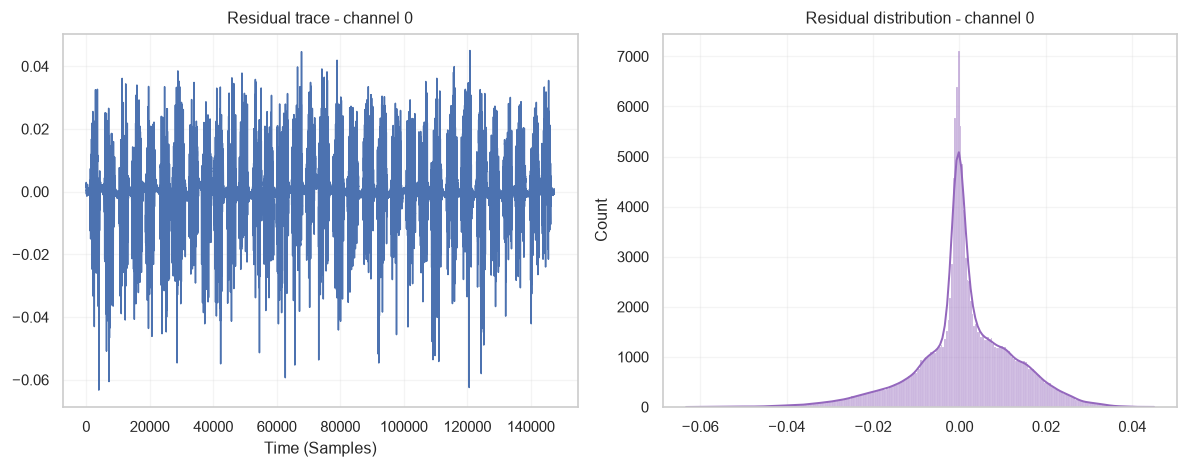

In [260]:
plot_residual_diagnostics(pred_full, target_full, channel_idx=0, cfg=notebook_cfg);

Saved figure:
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\fused_pca_scatter.png
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\fused_pca_scatter.pdf


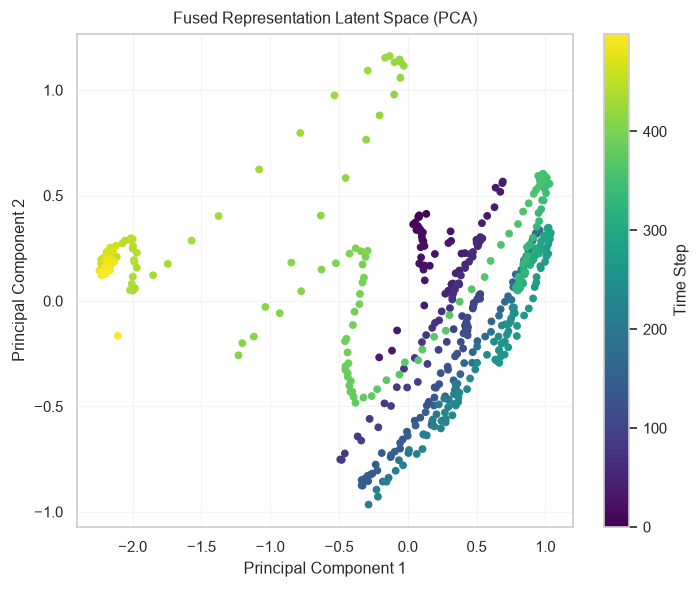

In [262]:
plot_fused_pca(interpret_dict["fused"], sample_idx=0, cfg=notebook_cfg);

Saved figure:
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\gate_vs_emg_power.png
  results\ep50_st150_lr0.0001_bs64\fold_5\plots\gate_vs_emg_power.pdf


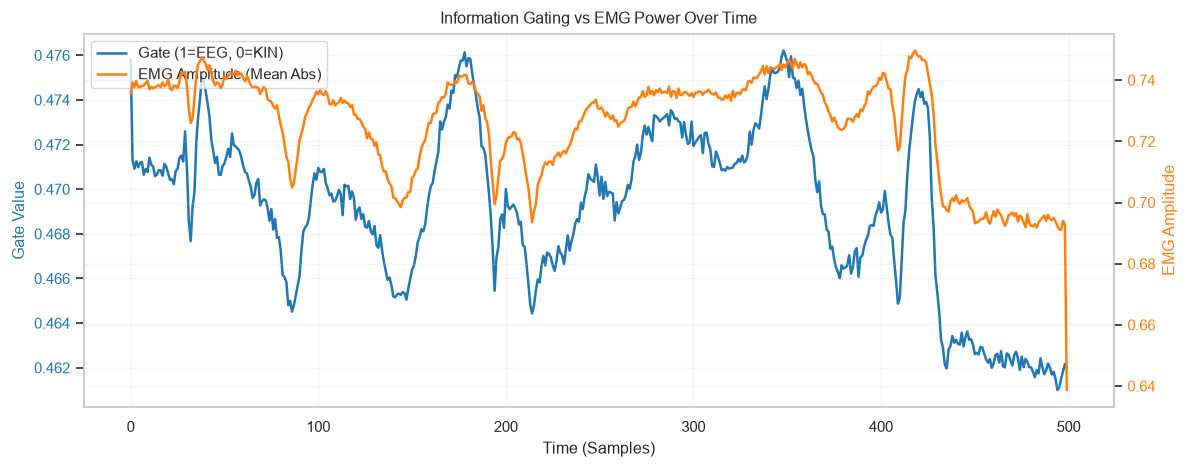

In [263]:
plot_gate_vs_emg_power(interpret_dict["gate"], preds, sample_idx=0, cfg=notebook_cfg);
